# PMCI paper code — Main


## Original cell 21: CIAS MINIMAL PIPELINE


In [ ]:
# ============================================================
# CIAS MINIMAL PIPELINE
# RAVDESS 12 actors + MELD subset
# ============================================================

!pip -q install ultralytics opencv-python-headless requests tqdm scikit-learn pandas matplotlib

import os, gc, cv2, zipfile, tarfile, shutil, random, math, requests, warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
from pathlib import Path
from tqdm import tqdm

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

from ultralytics import YOLO
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import roc_auc_score, average_precision_score, accuracy_score, f1_score

# ============================================================
# 0. CONFIG
# ============================================================

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print("Device:", DEVICE)

BASE_DIR = "/content/cias_q1_min"
TMP_DIR = "/content/cias_tmp"

RAVDESS_SHARD_DIR = f"{BASE_DIR}/shards/RAVDESS"
MELD_SHARD_DIR    = f"{BASE_DIR}/shards/MELD"
RESULT_DIR        = f"{BASE_DIR}/results"

for d in [BASE_DIR, TMP_DIR, RAVDESS_SHARD_DIR, MELD_SHARD_DIR, RESULT_DIR]:
    os.makedirs(d, exist_ok=True)

# ---------- Dataset minimal Q1 setting ----------
PROCESS_RAVDESS = True
PROCESS_MELD = True

RAVDESS_ACTORS = list(range(1, 13))   # Q1 minimum: 12 actors
MELD_MAX_CLIPS = 800                  # Q1 minimum external noisy subset

# ---------- Pose/window setting ----------
TARGET_FPS = 3
WINDOW_T = 12
STRIDE = 6
MAX_FRAMES_PER_VIDEO = 90
YOLO_BATCH = 1

# ---------- Training setting ----------
EPOCHS = 8
BATCH_SIZE = 64
LR = 1e-3
HIDDEN = 96
EMBED = 96
K_PROTO = 8
TEMP = 0.25

N_EVAL_PAIRS = 2000
TRAIN_PAIR_MULTIPLIER = 4
MIN_WINDOWS = 80

FACE_IDX = [0, 1, 2, 3, 4]
BODY_IDX = [5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16]

print("Base dir:", BASE_DIR)

# ============================================================
# 1. UTILITIES
# ============================================================

def clean_memory():
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()

def download_file(url, out_path, chunk_size=1024*1024):
    if os.path.exists(out_path) and os.path.getsize(out_path) > 0:
        print("[exists]", out_path)
        return out_path

    print("[download]", url)
    print("[to]", out_path)

    with requests.get(url, stream=True, allow_redirects=True) as r:
        r.raise_for_status()
        total = int(r.headers.get("content-length", 0))

        with open(out_path, "wb") as f, tqdm(
            total=total,
            unit="B",
            unit_scale=True,
            desc=os.path.basename(out_path)
        ) as pbar:
            for chunk in r.iter_content(chunk_size=chunk_size):
                if chunk:
                    f.write(chunk)
                    pbar.update(len(chunk))

    return out_path

def safe_rmtree(path):
    if os.path.exists(path):
        shutil.rmtree(path)

def find_videos(root, limit=None):
    exts = [".mp4", ".avi", ".mov", ".mkv", ".webm"]
    files = []
    for p in Path(root).rglob("*"):
        if p.suffix.lower() in exts:
            files.append(str(p))
    files = sorted(files)
    if limit is not None:
        files = files[:limit]
    return files

def count_shards(shard_dir):
    return len(list(Path(shard_dir).glob("*.npz")))

# ============================================================
# 2. POSE EXTRACTION
# ============================================================

def normalize_keypoints(xy):
    xy = np.array(xy, dtype=np.float32)

    if xy.shape[0] < 17:
        return None, None

    xy[~np.isfinite(xy)] = 0

    core = xy[[5, 6, 11, 12]]
    center = core.mean(axis=0)

    shoulder = np.linalg.norm(xy[5] - xy[6])
    torso = np.linalg.norm(((xy[5] + xy[6]) / 2) - ((xy[11] + xy[12]) / 2))
    scale = max(shoulder, torso, 30.0)

    xy = (xy - center) / scale

    face = xy[FACE_IDX].reshape(-1).astype(np.float32)  # 10
    body = xy[BODY_IDX].reshape(-1).astype(np.float32)  # 24

    return face, body

def add_derivatives(x):
    d1 = np.zeros_like(x)
    d2 = np.zeros_like(x)

    d1[1:] = x[1:] - x[:-1]
    d2[2:] = x[2:] - x[:-2]

    return np.concatenate([x, d1, d2], axis=-1).astype(np.float32)

def make_windows(face_seq, body_seq):
    if len(face_seq) < WINDOW_T:
        return [], []

    Fseq = add_derivatives(np.stack(face_seq))  # [T, 30]
    Bseq = add_derivatives(np.stack(body_seq))  # [T, 72]

    Fw, Bw = [], []

    for s in range(0, len(Fseq) - WINDOW_T + 1, STRIDE):
        f = Fseq[s:s+WINDOW_T]
        b = Bseq[s:s+WINDOW_T]

        if np.abs(f).sum() < 1e-6 or np.abs(b).sum() < 1e-6:
            continue

        Fw.append(f)
        Bw.append(b)

    return Fw, Bw

def process_video(video_path, model):
    cap = cv2.VideoCapture(video_path)

    if not cap.isOpened():
        return [], []

    fps = cap.get(cv2.CAP_PROP_FPS)
    if fps is None or fps <= 1:
        fps = 30

    step = max(1, int(round(fps / TARGET_FPS)))

    faces, bodies = [], []
    last_f = np.zeros(10, dtype=np.float32)
    last_b = np.zeros(24, dtype=np.float32)

    idx = 0
    used = 0

    while True:
        ok, frame = cap.read()
        if not ok:
            break

        if idx % step == 0:
            frame = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)

            try:
                res = model.predict(
                    frame,
                    verbose=False,
                    device=0 if DEVICE == "cuda" else "cpu"
                )[0]

                if res.keypoints is not None and res.keypoints.xy is not None and len(res.keypoints.xy) > 0:
                    xy_all = res.keypoints.xy.detach().cpu().numpy()

                    if res.keypoints.conf is not None:
                        conf = res.keypoints.conf.detach().cpu().numpy()
                        person = int(np.argmax(conf.sum(axis=1)))
                    else:
                        person = 0

                    f, b = normalize_keypoints(xy_all[person])

                    if f is not None:
                        last_f = f
                        last_b = b

                faces.append(last_f.copy())
                bodies.append(last_b.copy())

            except Exception:
                faces.append(last_f.copy())
                bodies.append(last_b.copy())

            used += 1

            if used >= MAX_FRAMES_PER_VIDEO:
                break

        idx += 1

    cap.release()
    clean_memory()

    return make_windows(faces, bodies)

# ============================================================
# 3. SHARD WRITER
# ============================================================

class ShardWriter:
    def __init__(self, shard_dir, dataset_name, shard_size=500):
        self.shard_dir = shard_dir
        self.dataset_name = dataset_name
        self.shard_size = shard_size
        os.makedirs(shard_dir, exist_ok=True)

        self.face = []
        self.body = []
        self.video_ids = []
        self.subject_ids = []
        self.counter = count_shards(shard_dir)

    def add(self, f, b, video_id, subject_id):
        self.face.append(f)
        self.body.append(b)
        self.video_ids.append(video_id)
        self.subject_ids.append(subject_id)

        if len(self.face) >= self.shard_size:
            self.flush()

    def flush(self):
        if len(self.face) == 0:
            return

        out_path = os.path.join(
            self.shard_dir,
            f"{self.dataset_name}_shard_{self.counter:05d}.npz"
        )

        np.savez_compressed(
            out_path,
            face=np.array(self.face, dtype=np.float32),
            body=np.array(self.body, dtype=np.float32),
            video_ids=np.array(self.video_ids),
            subject_ids=np.array(self.subject_ids),
            dataset=np.array([self.dataset_name] * len(self.face))
        )

        print("[saved]", out_path, "windows:", len(self.face))

        self.face, self.body, self.video_ids, self.subject_ids = [], [], [], []
        self.counter += 1
        clean_memory()

# ============================================================
# 4. DOWNLOAD + PROCESS RAVDESS
# ============================================================

def process_ravdess():
    print("\n" + "="*80)
    print("RAVDESS PROCESSING")
    print("="*80)

    done_file = os.path.join(RAVDESS_SHARD_DIR, "_RAVDESS_DONE.txt")
    if os.path.exists(done_file):
        print("[skip] RAVDESS already processed.")
        return

    model = YOLO("yolov8n-pose.pt")
    writer = ShardWriter(RAVDESS_SHARD_DIR, "RAVDESS", shard_size=500)

    record = requests.get("https://zenodo.org/api/records/1188976").json()
    files = record["files"]

    selected = []

    for f in files:
        key = f["key"]
        for actor in RAVDESS_ACTORS:
            if key == f"Video_Speech_Actor_{actor:02d}.zip":
                selected.append(f)

    print("Selected actors:", RAVDESS_ACTORS)
    print("Selected zip files:", len(selected))

    for f in selected:
        key = f["key"]
        actor_id = key.split("_Actor_")[-1].replace(".zip", "")

        marker = os.path.join(RAVDESS_SHARD_DIR, f".done_{key}")
        if os.path.exists(marker):
            print("[skip actor]", key)
            continue

        print("\n" + "-"*70)
        print("Actor zip:", key)
        print("-"*70)

        zip_path = os.path.join(TMP_DIR, key)
        extract_dir = os.path.join(TMP_DIR, key.replace(".zip", ""))

        safe_rmtree(extract_dir)

        url = f["links"].get("self") or f["links"].get("download")
        download_file(url, zip_path)

        os.makedirs(extract_dir, exist_ok=True)
        with zipfile.ZipFile(zip_path, "r") as z:
            z.extractall(extract_dir)

        videos = find_videos(extract_dir)
        print("Videos:", len(videos))

        for vp in tqdm(videos, desc=f"RAVDESS actor {actor_id}"):
            try:
                Fw, Bw = process_video(vp, model)

                vid = f"ravdess_actor_{actor_id}_" + os.path.basename(vp)

                for i in range(len(Fw)):
                    writer.add(Fw[i], Bw[i], vid, actor_id)

            except Exception as e:
                print("Skip video:", vp, str(e)[:120])

        writer.flush()

        safe_rmtree(extract_dir)
        if os.path.exists(zip_path):
            os.remove(zip_path)

        Path(marker).write_text("done")
        clean_memory()

    writer.flush()
    Path(done_file).write_text("done")
    print("RAVDESS done. Shards:", count_shards(RAVDESS_SHARD_DIR))

# ============================================================
# 5. DOWNLOAD + PROCESS MELD
# ============================================================

def extract_tar(tar_path, out_dir):
    os.makedirs(out_dir, exist_ok=True)
    with tarfile.open(tar_path, "r:*") as tar:
        tar.extractall(out_dir)

def process_meld():
    print("\n" + "="*80)
    print("MELD PROCESSING")
    print("="*80)

    done_file = os.path.join(MELD_SHARD_DIR, "_MELD_DONE.txt")
    if os.path.exists(done_file):
        print("[skip] MELD already processed.")
        return

    model = YOLO("yolov8n-pose.pt")
    writer = ShardWriter(MELD_SHARD_DIR, "MELD", shard_size=500)

    meld_root = os.path.join(TMP_DIR, "MELD")
    meld_tar = os.path.join(TMP_DIR, "MELD.Raw.tar.gz")
    meld_url = "http://web.eecs.umich.edu/~mihalcea/downloads/MELD.Raw.tar.gz"

    if not os.path.exists(meld_root):
        download_file(meld_url, meld_tar)
        extract_tar(meld_tar, meld_root)

        inner = list(Path(meld_root).rglob("*.tar.gz"))
        for a in inner:
            out_dir = str(a).replace(".tar.gz", "")
            if not os.path.exists(out_dir):
                extract_tar(str(a), out_dir)

    videos = find_videos(meld_root, limit=MELD_MAX_CLIPS)
    print("MELD selected clips:", len(videos))

    for idx, vp in enumerate(tqdm(videos, desc="MELD clips")):
        try:
            Fw, Bw = process_video(vp, model)

            rel = os.path.relpath(vp, meld_root)
            subject_id = "unknown"

            for i in range(len(Fw)):
                writer.add(Fw[i], Bw[i], f"meld_{idx}_{rel}", subject_id)

        except Exception as e:
            print("Skip MELD:", vp, str(e)[:120])

    writer.flush()

    # Чтобы освободить диск после pose extraction
    safe_rmtree(meld_root)
    if os.path.exists(meld_tar):
        os.remove(meld_tar)

    Path(done_file).write_text("done")
    print("MELD done. Shards:", count_shards(MELD_SHARD_DIR))

# ============================================================
# 6. LOAD SHARDS
# ============================================================

def load_shards(shard_dir, dataset_name):
    files = sorted(Path(shard_dir).glob("*.npz"))

    faces, bodies, vids, subs, dsets = [], [], [], [], []

    for fp in files:
        z = np.load(fp, allow_pickle=True)

        if "face" not in z:
            continue

        faces.append(z["face"])
        bodies.append(z["body"])
        vids.append(z["video_ids"])
        subs.append(z["subject_ids"])
        dsets.append(z["dataset"])

    if len(faces) == 0:
        return None

    data = {
        "face": np.concatenate(faces, axis=0).astype(np.float32),
        "body": np.concatenate(bodies, axis=0).astype(np.float32),
        "video_ids": np.concatenate(vids, axis=0).astype(str),
        "subject_ids": np.concatenate(subs, axis=0).astype(str),
        "dataset": np.concatenate(dsets, axis=0).astype(str),
    }

    print(dataset_name, "loaded:")
    print("face:", data["face"].shape)
    print("body:", data["body"].shape)
    print("videos:", len(set(data["video_ids"])))

    return data

def subset(data, mask):
    return {
        "face": data["face"][mask],
        "body": data["body"][mask],
        "video_ids": data["video_ids"][mask],
        "subject_ids": data["subject_ids"][mask],
        "dataset": data["dataset"][mask],
    }

def split_by_video(data, test_size=0.2, val_size=0.1):
    vids = np.array(sorted(list(set(data["video_ids"]))))

    if len(vids) < 5:
        idx = np.arange(len(data["face"]))
        tr, te = train_test_split(idx, test_size=test_size, random_state=SEED)
        tr, va = train_test_split(tr, test_size=val_size, random_state=SEED)

        mtr = np.zeros(len(idx), dtype=bool)
        mva = np.zeros(len(idx), dtype=bool)
        mte = np.zeros(len(idx), dtype=bool)

        mtr[tr] = True
        mva[va] = True
        mte[te] = True
        return mtr, mva, mte

    train_vids, test_vids = train_test_split(vids, test_size=test_size, random_state=SEED)
    train_vids, val_vids = train_test_split(train_vids, test_size=val_size, random_state=SEED)

    mtr = np.isin(data["video_ids"], train_vids)
    mva = np.isin(data["video_ids"], val_vids)
    mte = np.isin(data["video_ids"], test_vids)

    return mtr, mva, mte

def standardize_fit_apply(train, val, test):
    fs = StandardScaler()
    bs = StandardScaler()

    F = train["face"]
    B = train["body"]

    fs.fit(F.reshape(-1, F.shape[-1]))
    bs.fit(B.reshape(-1, B.shape[-1]))

    def apply(d):
        F = d["face"]
        B = d["body"]

        return {
            "face": fs.transform(F.reshape(-1, F.shape[-1])).reshape(F.shape).astype(np.float32),
            "body": bs.transform(B.reshape(-1, B.shape[-1])).reshape(B.shape).astype(np.float32),
            "video_ids": d["video_ids"],
            "subject_ids": d["subject_ids"],
            "dataset": d["dataset"],
        }

    return apply(train), apply(val), apply(test)

# ============================================================
# 7. PAIR SAMPLING
# ============================================================

class PairSampler:
    def __init__(self, data):
        self.face = data["face"]
        self.body = data["body"]
        self.video_ids = np.array(data["video_ids"])
        self.n = len(self.face)

        self.vid_to_idx = {}
        for i, v in enumerate(self.video_ids):
            self.vid_to_idx.setdefault(v, []).append(i)

        self.videos = list(self.vid_to_idx.keys())

    def positive(self):
        i = random.randrange(self.n)
        return i, i, 1

    def cross(self):
        i = random.randrange(self.n)
        vi = self.video_ids[i]

        for _ in range(50):
            j = random.randrange(self.n)
            if self.video_ids[j] != vi:
                return i, j, 0

        return i, random.randrange(self.n), 0

    def same(self):
        possible = [v for v in self.videos if len(self.vid_to_idx[v]) >= 2]

        if len(possible) == 0:
            return self.cross()

        v = random.choice(possible)
        i, j = random.sample(self.vid_to_idx[v], 2)
        return i, j, 0

    def shift(self):
        possible = [v for v in self.videos if len(self.vid_to_idx[v]) >= 2]

        if len(possible) == 0:
            return self.cross()

        v = random.choice(possible)
        idxs = sorted(self.vid_to_idx[v])

        pos = random.randrange(len(idxs))
        delta = random.choice([-2, -1, 1, 2])
        pos2 = min(max(pos + delta, 0), len(idxs) - 1)

        if pos2 == pos:
            return self.cross()

        return idxs[pos], idxs[pos2], 0

    def shuffle(self):
        i = random.randrange(self.n)
        j = random.randrange(self.n)

        if i == j:
            return self.cross()

        return i, j, 0

    def mixed_negative(self):
        r = random.choice(["cross", "same", "shift", "shuffle"])

        if r == "cross":
            return self.cross()
        if r == "same":
            return self.same()
        if r == "shift":
            return self.shift()

        return self.shuffle()

class PairDataset(Dataset):
    def __init__(self, data, length):
        self.data = data
        self.sampler = PairSampler(data)
        self.length = length

    def __len__(self):
        return self.length

    def __getitem__(self, idx):
        if random.random() < 0.5:
            i, j, y = self.sampler.positive()
        else:
            i, j, y = self.sampler.mixed_negative()

        return (
            torch.tensor(self.data["face"][i], dtype=torch.float32),
            torch.tensor(self.data["body"][j], dtype=torch.float32),
            torch.tensor([y], dtype=torch.float32),
        )

# ============================================================
# 8. MODEL
# ============================================================

class CIASNet(nn.Module):
    def __init__(self, face_dim=30, body_dim=72):
        super().__init__()

        self.face_gru = nn.GRU(face_dim, HIDDEN, batch_first=True, bidirectional=True)
        self.body_gru = nn.GRU(body_dim, HIDDEN, batch_first=True, bidirectional=True)

        self.face_proj = nn.Sequential(
            nn.Linear(HIDDEN * 2, EMBED),
            nn.ReLU(),
            nn.LayerNorm(EMBED)
        )

        self.body_proj = nn.Sequential(
            nn.Linear(HIDDEN * 2, EMBED),
            nn.ReLU(),
            nn.LayerNorm(EMBED)
        )

        self.prototypes = nn.Parameter(torch.randn(K_PROTO, EMBED) * 0.02)

        self.logit_scale = nn.Parameter(torch.tensor(8.0))
        self.logit_bias = nn.Parameter(torch.tensor(-4.0))

    def encode_face(self, x):
        _, h = self.face_gru(x)
        h = torch.cat([h[-2], h[-1]], dim=-1)
        z = self.face_proj(h)
        return F.normalize(z, dim=-1)

    def encode_body(self, x):
        _, h = self.body_gru(x)
        h = torch.cat([h[-2], h[-1]], dim=-1)
        z = self.body_proj(h)
        return F.normalize(z, dim=-1)

    def dist(self, z):
        p = F.normalize(self.prototypes, dim=-1)
        logits = torch.matmul(z, p.t()) / TEMP
        return F.softmax(logits, dim=-1)

    def js(self, p, q, eps=1e-8):
        p = p.clamp(min=eps)
        q = q.clamp(min=eps)

        m = 0.5 * (p + q)

        kl1 = torch.sum(p * torch.log(p / m), dim=-1)
        kl2 = torch.sum(q * torch.log(q / m), dim=-1)

        js = 0.5 * (kl1 + kl2) / math.log(2.0)
        return js

    def forward(self, face, body):
        zf = self.encode_face(face)
        zb = self.encode_body(body)

        pf = self.dist(zf)
        pb = self.dist(zb)

        js = self.js(pf, pb)
        ec = 1.0 - js

        emb_cos = torch.sum(zf * zb, dim=-1)
        prob_cos = F.cosine_similarity(pf, pb, dim=-1)

        symkl = torch.sum(pf * torch.log((pf + 1e-8) / (pb + 1e-8)), dim=-1)
        symkl += torch.sum(pb * torch.log((pb + 1e-8) / (pf + 1e-8)), dim=-1)
        symkl = 0.5 * symkl

        logit = self.logit_scale * ec + self.logit_bias

        return {
            "logit": logit.unsqueeze(-1),
            "ec_js": ec,
            "emb_cos": emb_cos,
            "prob_cos": prob_cos,
            "neg_symkl": -symkl,
            "pf": pf,
            "pb": pb,
            "zf": zf,
            "zb": zb,
        }

# ============================================================
# 9. TRAIN + EVAL
# ============================================================

def train_model(train, val=None, name="model"):
    model = CIASNet(
        face_dim=train["face"].shape[-1],
        body_dim=train["body"].shape[-1],
    ).to(DEVICE)

    length = max(4000, len(train["face"]) * TRAIN_PAIR_MULTIPLIER)
    ds = PairDataset(train, length=length)
    dl = DataLoader(ds, batch_size=BATCH_SIZE, shuffle=True, num_workers=0)

    opt = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=1e-4)

    best_auc = -1
    best_state = None

    for ep in range(1, EPOCHS + 1):
        model.train()
        losses = []

        for face, body, y in dl:
            face = face.to(DEVICE)
            body = body.to(DEVICE)
            y = y.to(DEVICE)

            out = model(face, body)
            loss = F.binary_cross_entropy_with_logits(out["logit"], y)

            opt.zero_grad()
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 5.0)
            opt.step()

            losses.append(loss.item())

        msg = f"{name} | epoch {ep:02d} | loss={np.mean(losses):.4f}"

        if val is not None and len(val["face"]) >= MIN_WINDOWS:
            res = evaluate_all(model, val, n_pairs=800, quiet=True)
            mean_auc = np.mean([v["ec_js_auc"] for v in res.values() if not np.isnan(v["ec_js_auc"])])
            msg += f" | val_mean_auc={mean_auc:.4f}"

            if mean_auc > best_auc:
                best_auc = mean_auc
                best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}

        print(msg)

    if best_state is not None:
        model.load_state_dict(best_state)

    return model

def make_eval_pairs(data, regime, n_pairs):
    sampler = PairSampler(data)
    pairs = []

    half = n_pairs // 2

    for _ in range(half):
        pairs.append(sampler.positive())

    for _ in range(n_pairs - half):
        if regime == "cross":
            pairs.append(sampler.cross())
        elif regime == "same":
            pairs.append(sampler.same())
        elif regime == "shift":
            pairs.append(sampler.shift())
        elif regime == "shuffle":
            pairs.append(sampler.shuffle())
        else:
            raise ValueError(regime)

    random.shuffle(pairs)
    return pairs

@torch.no_grad()
def score_pairs(model, data, pairs):
    model.eval()

    labels = []
    scores = {
        "ec_js": [],
        "emb_cos": [],
        "prob_cos": [],
        "neg_symkl": [],
    }

    for s in range(0, len(pairs), 256):
        batch = pairs[s:s+256]

        fi = [x[0] for x in batch]
        bj = [x[1] for x in batch]
        yy = [x[2] for x in batch]

        face = torch.tensor(data["face"][fi], dtype=torch.float32).to(DEVICE)
        body = torch.tensor(data["body"][bj], dtype=torch.float32).to(DEVICE)

        out = model(face, body)

        for k in scores:
            scores[k].extend(out[k].detach().cpu().numpy().tolist())

        labels.extend(yy)

    return {k: np.array(v) for k, v in scores.items()}, np.array(labels)

def metric_auc(scores, labels):
    if len(set(labels.tolist())) < 2:
        return np.nan
    return float(roc_auc_score(labels, scores))

def evaluate_regime(model, data, regime, n_pairs=N_EVAL_PAIRS):
    pairs = make_eval_pairs(data, regime, n_pairs)
    scores, labels = score_pairs(model, data, pairs)

    res = {}

    for k, sc in scores.items():
        res[f"{k}_auc"] = metric_auc(sc, labels)
        res[f"{k}_pos_mean"] = float(sc[labels == 1].mean())
        res[f"{k}_neg_mean"] = float(sc[labels == 0].mean())

    return res

def evaluate_all(model, data, n_pairs=N_EVAL_PAIRS, quiet=False):
    regimes = ["cross", "same", "shift", "shuffle"]
    out = {}

    for r in regimes:
        res = evaluate_regime(model, data, r, n_pairs)
        out[r] = res

        if not quiet:
            print(
                f"{r:8s} | "
                f"CIAS_JS_AUC={res['ec_js_auc']:.4f} | "
                f"EmbCos_AUC={res['emb_cos_auc']:.4f} | "
                f"ProbCos_AUC={res['prob_cos_auc']:.4f} | "
                f"NegSymKL_AUC={res['neg_symkl_auc']:.4f}"
            )

    return out

# ============================================================
# 10. EXPERIMENT RUNNERS
# ============================================================

def prepare_dataset(data):
    mtr, mva, mte = split_by_video(data)

    raw_train = subset(data, mtr)
    raw_val = subset(data, mva)
    raw_test = subset(data, mte)

    train, val, test = standardize_fit_apply(raw_train, raw_val, raw_test)

    return train, val, test

def run_within(name, data):
    print("\n" + "="*80)
    print("WITHIN:", name)
    print("="*80)

    if data is None or len(data["face"]) < MIN_WINDOWS:
        print("Not enough windows:", 0 if data is None else len(data["face"]))
        return None, []

    train, val, test = prepare_dataset(data)

    print("Train:", len(train["face"]), "Val:", len(val["face"]), "Test:", len(test["face"]))

    model = train_model(train, val, name=f"{name}_within")

    print("\nTEST:", name)
    results = evaluate_all(model, test, n_pairs=N_EVAL_PAIRS)

    rows = []
    for regime, metrics in results.items():
        rows.append({
            "experiment": "within",
            "train": name,
            "test": name,
            "regime": regime,
            **metrics
        })

    return model, rows

def fit_scaler_source_apply(source_train, source_val, target_test):
    fs = StandardScaler()
    bs = StandardScaler()

    fs.fit(source_train["face"].reshape(-1, source_train["face"].shape[-1]))
    bs.fit(source_train["body"].reshape(-1, source_train["body"].shape[-1]))

    def apply(d):
        F = d["face"]
        B = d["body"]
        return {
            "face": fs.transform(F.reshape(-1, F.shape[-1])).reshape(F.shape).astype(np.float32),
            "body": bs.transform(B.reshape(-1, B.shape[-1])).reshape(B.shape).astype(np.float32),
            "video_ids": d["video_ids"],
            "subject_ids": d["subject_ids"],
            "dataset": d["dataset"],
        }

    return apply(source_train), apply(source_val), apply(target_test)

def run_cross(train_name, train_data, test_name, test_data):
    print("\n" + "="*80)
    print(f"CROSS: train {train_name} -> test {test_name}")
    print("="*80)

    if train_data is None or test_data is None:
        return []

    if len(train_data["face"]) < MIN_WINDOWS or len(test_data["face"]) < MIN_WINDOWS:
        print("Not enough data for cross.")
        return []

    mtr, mva, _ = split_by_video(train_data)
    _, _, mte_target = split_by_video(test_data)

    raw_train = subset(train_data, mtr)
    raw_val = subset(train_data, mva)
    raw_target = subset(test_data, mte_target)

    train, val, target = fit_scaler_source_apply(raw_train, raw_val, raw_target)

    print("Source train:", len(train["face"]), "Source val:", len(val["face"]), "Target test:", len(target["face"]))

    model = train_model(train, val, name=f"{train_name}_to_{test_name}")

    print("\nTARGET TEST:", test_name)
    results = evaluate_all(model, target, n_pairs=N_EVAL_PAIRS)

    rows = []
    for regime, metrics in results.items():
        rows.append({
            "experiment": "cross_transfer",
            "train": train_name,
            "test": test_name,
            "regime": regime,
            **metrics
        })

    return rows

# ============================================================
# 11. MAIN
# ============================================================

if PROCESS_RAVDESS:
    process_ravdess()

if PROCESS_MELD:
    process_meld()

print("\n" + "="*80)
print("LOAD CACHES")
print("="*80)

ravdess = load_shards(RAVDESS_SHARD_DIR, "RAVDESS")
meld = load_shards(MELD_SHARD_DIR, "MELD")

datasets = {}
if ravdess is not None and len(ravdess["face"]) >= MIN_WINDOWS:
    datasets["RAVDESS"] = ravdess

if meld is not None and len(meld["face"]) >= MIN_WINDOWS:
    datasets["MELD"] = meld

print("Available datasets:", list(datasets.keys()))

all_rows = []

# Within dataset
for name, data in datasets.items():
    model, rows = run_within(name, data)
    all_rows.extend(rows)
    clean_memory()

# Cross transfer
names = list(datasets.keys())

for a in names:
    for b in names:
        if a == b:
            continue
        rows = run_cross(a, datasets[a], b, datasets[b])
        all_rows.extend(rows)
        clean_memory()

# Save result table
df = pd.DataFrame(all_rows)

result_csv = os.path.join(RESULT_DIR, "cias_q1_min_results.csv")
df.to_csv(result_csv, index=False)

print("\n" + "="*80)
print("FINAL RESULTS")
print("="*80)

display(df)

if len(df) > 0:
    pivot = df.pivot_table(
        index=["experiment", "train", "test"],
        columns="regime",
        values="ec_js_auc",
        aggfunc="mean"
    ).reset_index()

    print("\nCIAS JS AUC PIVOT")
    display(pivot)

    pivot_path = os.path.join(RESULT_DIR, "cias_q1_min_pivot.csv")
    pivot.to_csv(pivot_path, index=False)

    print("Saved:")
    print(result_csv)
    print(pivot_path)

print("\nDONE.")
print("All files are in:", BASE_DIR)

## Original cell 25: REBUILD MELD SHARD EXACTLY 402 WINDOWS


In [ ]:
# ============================================================
# REBUILD MELD SHARD EXACTLY 402 WINDOWS
# Uses already extracted MELD videos
# ============================================================

import os, gc
import numpy as np
from pathlib import Path
from tqdm import tqdm
from ultralytics import YOLO
import torch

MELD_TMP_ROOT = "/content/cias_q1_min/raw/MELD"
MELD_SHARD_DIR = "/content/cias_q1_min/shards/MELD"
TARGET_WINDOWS = 402
MAX_SCAN_CLIPS = 1200

Path(MELD_SHARD_DIR).mkdir(parents=True, exist_ok=True)

# удалить старые MELD shards
for fp in Path(MELD_SHARD_DIR).glob("*.npz"):
    os.remove(fp)

done_file = f"{MELD_SHARD_DIR}/_MELD_DONE.txt"
if os.path.exists(done_file):
    os.remove(done_file)

videos = sorted([
    str(p) for p in Path(MELD_TMP_ROOT).rglob("*")
    if p.suffix.lower() in [".mp4", ".avi", ".mov", ".mkv", ".webm"]
])

print("Total MELD videos found:", len(videos))
videos = videos[:MAX_SCAN_CLIPS]
print("Scanning clips:", len(videos))

model = YOLO("yolov8n-pose.pt")

faces = []
bodies = []
video_ids = []
subject_ids = []
datasets = []

for idx, vp in enumerate(tqdm(videos, desc="MELD -> 402 windows")):
    try:
        Fw, Bw = process_video(vp, model)

        if len(Fw) == 0:
            continue

        rel = os.path.relpath(vp, MELD_TMP_ROOT)

        for i in range(len(Fw)):
            if len(faces) >= TARGET_WINDOWS:
                break

            faces.append(Fw[i].astype(np.float32))
            bodies.append(Bw[i].astype(np.float32))
            video_ids.append(f"meld_{idx}_{rel}")
            subject_ids.append("unknown")
            datasets.append("MELD")

        if len(faces) >= TARGET_WINDOWS:
            break

    except Exception as e:
        print("Skip:", vp, str(e)[:120])

    if idx % 50 == 0:
        gc.collect()
        if torch.cuda.is_available():
            torch.cuda.empty_cache()

print("Collected windows:", len(faces))

if len(faces) < TARGET_WINDOWS:
    raise RuntimeError(f"Only collected {len(faces)} windows, target is {TARGET_WINDOWS}. Increase MAX_SCAN_CLIPS.")

out_path = f"{MELD_SHARD_DIR}/MELD_shard_00000.npz"

np.savez_compressed(
    out_path,
    face=np.stack(faces).astype(np.float32),
    body=np.stack(bodies).astype(np.float32),
    video_ids=np.array(video_ids).astype(str),
    subject_ids=np.array(subject_ids).astype(str),
    dataset=np.array(datasets).astype(str),
)

print("Saved:", out_path)
print("face:", np.stack(faces).shape)
print("body:", np.stack(bodies).shape)

# final check
z = np.load(out_path, allow_pickle=True)
print("CHECK face:", z["face"].shape)
print("CHECK body:", z["body"].shape)
print("CHECK videos:", len(set(z["video_ids"])))

Total MELD videos found: 15908
Scanning clips: 1200


MELD -> 402 windows:  67%|██████▋   | 802/1200 [06:14<03:05,  2.14it/s]

Collected windows: 402
Saved: /content/cias_q1_min/shards/MELD/MELD_shard_00000.npz
face: (402, 12, 30)
body: (402, 12, 72)
CHECK face: (402, 12, 30)
CHECK body: (402, 12, 72)
CHECK videos: 223


## Original cell 24: Basic article figures


Device: cuda

RAVDESS loaded: face (672, 12, 30), body (672, 12, 72), videos 672

MELD loaded: face (402, 12, 30), body (402, 12, 72), videos 223

RAVDESS actor split: 500 82 90

Emotion distribution in RAVDESS:
angry        144
disgust      144
calm         130
happy         80
sad           78
fearful       46
surprised     36
neutral       14
Name: count, dtype: int64

####################################################################################################
SEED: 42
####################################################################################################

RAVDESS actor-level | seed=42 | K=0
rav_actor | K=0 | seed=42 | epoch 01 | loss=0.3958 | val_auc=0.7405
rav_actor | K=0 | seed=42 | epoch 02 | loss=0.1909 | val_auc=0.7816
rav_actor | K=0 | seed=42 | epoch 03 | loss=0.1496 | val_auc=0.7793
rav_actor | K=0 | seed=42 | epoch 04 | loss=0.1191 | val_auc=0.8049
rav_actor | K=0 | seed=42 | epoch 05 | loss=0.0990 | val_auc=0.8430
rav_actor | K=0 | seed=42 | epoch 06 

,experiment,train,test,k_proto,regime,auc_mean,auc_std,pos_mean,neg_mean
0,meld_within,MELD,MELD,8,cross,0.738675,0.012977,0.571212,0.439002
1,meld_within,MELD,MELD,8,same,0.586380,0.008139,0.571212,0.526595
2,meld_within,MELD,MELD,8,shift,0.585614,0.007258,0.571212,0.528920
3,meld_within,MELD,MELD,8,shuffle,0.743620,0.024232,0.571212,0.436910
4,ravdess_actor_level,RAVDESS,RAVDESS,0,cross,0.929905,0.010804,0.555542,0.123943
5,ravdess_actor_level,RAVDESS,RAVDESS,0,same,0.923059,0.009050,0.555542,0.128899
6,ravdess_actor_level,RAVDESS,RAVDESS,0,shift,0.923059,0.009050,0.555542,0.128899
7,ravdess_actor_level,RAVDESS,RAVDESS,0,shuffle,0.926458,0.011500,0.555542,0.126629
8,ravdess_actor_level,RAVDESS,RAVDESS,8,cross,0.710697,0.047213,0.562293,0.437294
9,ravdess_actor_level,RAVDESS,RAVDESS,8,same,0.704050,0.054837,0.562293,0.440284



ADAPTATION CURVE


regime,experiment,train,test,k_proto,cross,same,shift,shuffle
0,ravdess_to_meld_adapt_0pct,RAVDESS+0%MELD,MELD,8,0.502088,0.507535,0.517001,0.497064
1,ravdess_to_meld_adapt_100pct,RAVDESS+100%MELD,MELD,8,0.590393,0.537326,0.541674,0.589775
2,ravdess_to_meld_adapt_10pct,RAVDESS+10%MELD,MELD,8,0.539638,0.536485,0.540005,0.534053
3,ravdess_to_meld_adapt_20pct,RAVDESS+20%MELD,MELD,8,0.565797,0.514970,0.518457,0.556941
4,ravdess_to_meld_adapt_50pct,RAVDESS+50%MELD,MELD,8,0.556097,0.509729,0.525146,0.558985



DROPOUT CONTROL SUMMARY


...

,k_proto,comparison,auc_mean,auc_std,p_mean,d_mean,pos_mean,neg_mean
0,0,same_emotion_diff_actor_vs_diff_emotion_diff_a...,0.588937,0.060675,0.004975,0.316505,0.044981,-0.003300
1,0,same_emotion_diff_actor_vs_same_actor_diff_emo...,0.294203,0.066754,1.000000,-0.782868,0.044981,0.198901
2,0,true_vs_random,0.921912,0.018528,0.004975,2.167559,0.531262,0.121507
3,0,true_vs_same_actor_diff_emotion,0.885216,0.024801,0.004975,1.753857,0.531262,0.198901
4,8,same_emotion_diff_actor_vs_diff_emotion_diff_a...,0.549425,0.012774,0.013267,0.169581,0.512830,0.482185
5,8,same_emotion_diff_actor_vs_same_actor_diff_emo...,0.622599,0.035747,0.004975,0.452592,0.512830,0.431043
6,8,true_vs_random,0.659423,0.075430,0.004975,0.616972,0.536092,0.444023
7,8,true_vs_same_actor_diff_emotion,0.679474,0.073654,0.004975,0.700489,0.536092,0.431043
8,16,same_emotion_diff_actor_vs_diff_emotion_diff_a...,0.546543,0.032742,0.126036,0.139054,0.435652,0.410943
9,16,same_emotion_diff_actor_vs_same_actor_diff_emo...,0.455079,0.111247,0.668325,-0.168838,0.435652,0.463037



BALANCED COUNTERFACTUAL PIVOT


k_proto,comparison,0,8,16,32
0,same_emotion_diff_actor_vs_diff_emotion_diff_a...,0.588937,0.549425,0.546543,0.541275
1,same_emotion_diff_actor_vs_same_actor_diff_emo...,0.294203,0.622599,0.455079,0.558389
2,true_vs_random,0.921912,0.659423,0.725354,0.709608
3,true_vs_same_actor_diff_emotion,0.885216,0.679474,0.670828,0.722566



PROTOTYPE USAGE SUMMARY


,dataset,k_proto,modality,entropy_mean,entropy_std,effective_k_mean,max_usage_mean,min_usage_mean
0,MELD,8,body,0.900919,0.042332,6.527014,0.235225,0.020232
1,MELD,8,face,0.820887,0.047868,5.530859,0.305909,0.009518
2,MELD_adapt_0pct,8,body,0.725471,0.153361,4.671883,0.459438,0.017204
3,MELD_adapt_0pct,8,face,0.704752,0.069042,4.358804,0.430327,0.008067
4,MELD_adapt_100pct,8,body,0.820849,0.050951,5.532950,0.351094,0.015585
5,MELD_adapt_100pct,8,face,0.704314,0.107209,4.394898,0.429508,0.006705
6,MELD_adapt_10pct,8,body,0.865225,0.005790,6.045009,0.365628,0.022444
7,MELD_adapt_10pct,8,face,0.743152,0.152220,4.839913,0.374131,0.007799
8,MELD_adapt_20pct,8,body,0.859713,0.065034,6.012130,0.346425,0.020386
9,MELD_adapt_20pct,8,face,0.725851,0.139104,4.646075,0.411811,0.007378


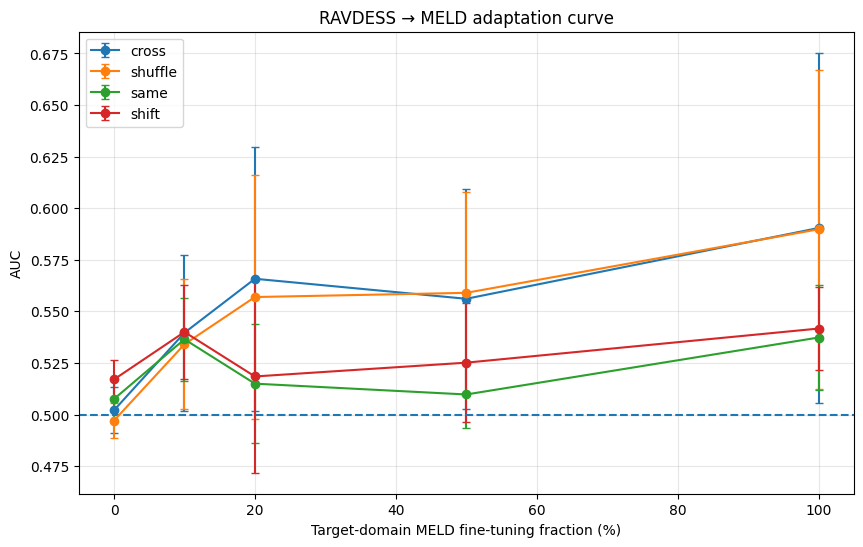

Saved plot: /content/cias_q1_min/results_q1_criticism_suite/plot_adaptation_curve.png


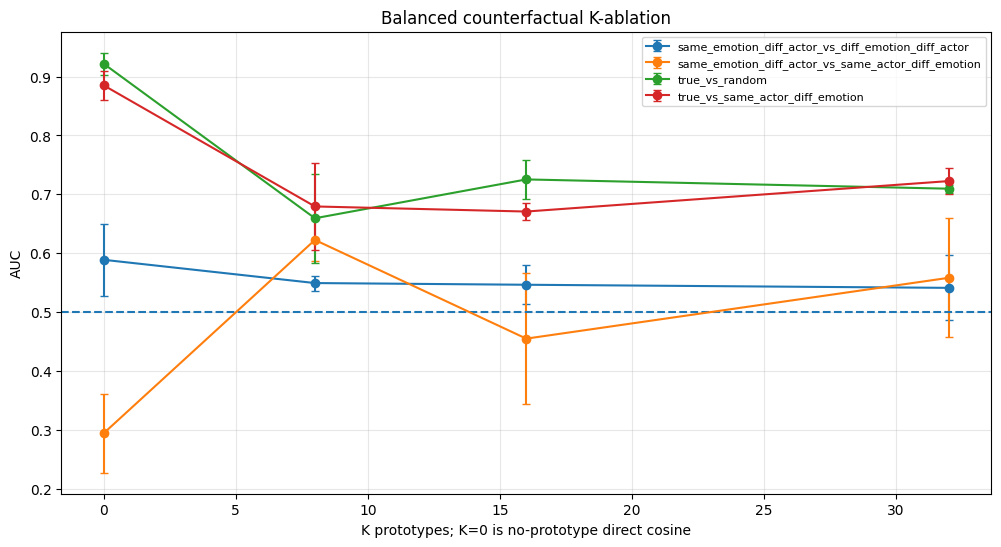

Saved plot: /content/cias_q1_min/results_q1_criticism_suite/plot_balanced_counterfactual_k.png

All outputs saved in: /content/cias_q1_min/results_q1_criticism_suite
DONE.


In [ ]:
!pip -q install scikit-learn pandas tqdm matplotlib openpyxl

import os, re, gc, math, random, warnings
warnings.filterwarnings('ignore')
import numpy as np, pandas as pd
from pathlib import Path
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score, balanced_accuracy_score, accuracy_score
from sklearn.linear_model import LogisticRegression
import matplotlib.pyplot as plt

BASE_DIR = '/content/cias_q1_min'
RAVDESS_SHARD_DIR = f'{BASE_DIR}/shards/RAVDESS'
MELD_SHARD_DIR = f'{BASE_DIR}/shards/MELD'
RESULT_DIR = f'{BASE_DIR}/results_q1_criticism_suite'
os.makedirs(RESULT_DIR, exist_ok=True)

DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
print('Device:', DEVICE)

SEEDS = [42, 43, 44]
K_LIST = [0, 8, 16, 32]
ADAPT_K = 8
EPOCHS = 7
EPOCHS_FT = 5
BATCH_SIZE = 64
LR = 1e-3
LR_FT = 3e-4
HIDDEN = 96
EMBED = 96
TEMP = 0.25
TRAIN_PAIR_MULTIPLIER = 6
N_EVAL_PAIRS = 1500
N_BALANCED_PAIRS_PER_EMOTION = 120
N_PERM = 200
ADAPT_FRACTIONS = [0.0, 0.10, 0.20, 0.50, 1.00]

EMOTION_MAP = {
    '01':'neutral','02':'calm','03':'happy','04':'sad','05':'angry','06':'fearful','07':'disgust','08':'surprised'
}

def set_seed(seed):
    random.seed(seed); np.random.seed(seed); torch.manual_seed(seed)
    if torch.cuda.is_available(): torch.cuda.manual_seed_all(seed)

def clean_memory():
    gc.collect()
    if torch.cuda.is_available(): torch.cuda.empty_cache()

def load_shards(shard_dir, name):
    files = sorted(Path(shard_dir).glob('*.npz'))
    if not files: raise RuntimeError(f'No shards found in {shard_dir}')
    faces,bodies,vids,subs,dsets=[],[],[],[],[]
    for fp in files:
        z=np.load(fp, allow_pickle=True)
        if 'face' not in z: continue
        faces.append(z['face']); bodies.append(z['body']); vids.append(z['video_ids']); subs.append(z['subject_ids']); dsets.append(z['dataset'])
    data={
        'face':np.concatenate(faces).astype(np.float32),
        'body':np.concatenate(bodies).astype(np.float32),
        'video_ids':np.concatenate(vids).astype(str),
        'subject_ids':np.concatenate(subs).astype(str),
        'dataset':np.concatenate(dsets).astype(str),
    }
    print(f'\n{name} loaded: face {data["face"].shape}, body {data["body"].shape}, videos {len(set(data["video_ids"]))}')
    return data

def parse_ravdess(video_id, fallback_actor=None):
    m=re.search(r'(\d{2}-\d{2}-\d{2}-\d{2}-\d{2}-\d{2}-\d{2})', str(video_id))
    if m is None: return 'unknown', str(fallback_actor)
    p=m.group(1).split('-')
    return p[2], p[6]

def add_ravdess_metadata(data):
    emos,names,actors=[],[],[]
    for vid, sub in zip(data['video_ids'], data['subject_ids']):
        emo,actor=parse_ravdess(vid, sub)
        emos.append(emo); names.append(EMOTION_MAP.get(emo,'unknown')); actors.append(actor)
    data['emotion_codes']=np.array(emos).astype(str)
    data['emotion_names']=np.array(names).astype(str)
    data['actor_ids']=np.array(actors).astype(str)
    return data

def add_meld_metadata(data):
    n=len(data['face'])
    data['actor_ids']=np.array(['unknown']*n)
    data['emotion_codes']=np.array(['unknown']*n)
    data['emotion_names']=np.array(['unknown']*n)
    return data

def subset(data, mask): return {k:v[mask] for k,v in data.items()}
def subset_idx(data, idx): return {k:v[idx] for k,v in data.items()}

def fit_scaler(train):
    fs,bs=StandardScaler(),StandardScaler()
    F,B=train['face'],train['body']
    fs.fit(F.reshape(-1,F.shape[-1])); bs.fit(B.reshape(-1,B.shape[-1]))
    return fs,bs

def apply_scaler(data, fs, bs):
    F,B=data['face'],data['body']
    out=dict(data)
    out['face']=fs.transform(F.reshape(-1,F.shape[-1])).reshape(F.shape).astype(np.float32)
    out['body']=bs.transform(B.reshape(-1,B.shape[-1])).reshape(B.shape).astype(np.float32)
    return out

def split_ravdess_by_actor(data):
    actors=sorted([a for a in set(data['actor_ids']) if a!='unknown'])
    if len(actors)>=24:
        tr=[f'{i:02d}' for i in range(1,17)]; va=[f'{i:02d}' for i in range(17,21)]; te=[f'{i:02d}' for i in range(21,25)]
    else:
        tr=[f'{i:02d}' for i in range(1,9)]; va=['09','10']; te=['11','12']
    a=np.array(data['actor_ids']).astype(str)
    train=subset(data,np.isin(a,tr)); val=subset(data,np.isin(a,va)); test=subset(data,np.isin(a,te))
    print('\nRAVDESS actor split:', len(train['face']), len(val['face']), len(test['face']))
    return train,val,test

def split_by_video(data, val_size=0.1, test_size=0.2, seed=42):
    vids=np.array(sorted(set(data['video_ids'])))
    tr_vids,te_vids=train_test_split(vids,test_size=test_size,random_state=seed)
    tr_vids,va_vids=train_test_split(tr_vids,test_size=val_size,random_state=seed)
    return subset(data,np.isin(data['video_ids'],tr_vids)), subset(data,np.isin(data['video_ids'],va_vids)), subset(data,np.isin(data['video_ids'],te_vids))

def sample_fraction(data, frac, seed):
    if frac<=0: return None
    n=len(data['face']); k=min(max(20,int(n*frac)),n)
    rng=np.random.default_rng(seed); idx=rng.choice(np.arange(n),size=k,replace=False)
    return subset_idx(data,idx)

def auc_pvalue(pos, neg, n_perm=200, seed=42):
    rng=np.random.default_rng(seed)
    scores=np.concatenate([pos,neg]); labels=np.concatenate([np.ones(len(pos)),np.zeros(len(neg))])
    real=roc_auc_score(labels,scores); c=0
    for _ in range(n_perm):
        if roc_auc_score(rng.permutation(labels), scores)>=real: c+=1
    return float(real), float((c+1)/(n_perm+1))

def cohen_d(pos, neg):
    pos,neg=np.asarray(pos),np.asarray(neg)
    if len(pos)<2 or len(neg)<2: return 0.0
    s1,s2=pos.std(ddof=1),neg.std(ddof=1); n1,n2=len(pos),len(neg)
    pooled=np.sqrt(((n1-1)*s1**2+(n2-1)*s2**2)/max(n1+n2-2,1))
    return 0.0 if pooled<1e-9 else float((pos.mean()-neg.mean())/pooled)

class PairDataset(Dataset):
    def __init__(self,data,length):
        self.data=data; self.length=length; self.n=len(data['face']); self.video_ids=np.array(data['video_ids'])
        self.vid_to_idx={}
        for i,v in enumerate(self.video_ids): self.vid_to_idx.setdefault(v,[]).append(i)
        self.videos=list(self.vid_to_idx.keys())
    def __len__(self): return self.length
    def positive(self):
        i=random.randrange(self.n); return i,i,1
    def cross_negative(self):
        i=random.randrange(self.n); vi=self.video_ids[i]
        for _ in range(50):
            j=random.randrange(self.n)
            if self.video_ids[j]!=vi: return i,j,0
        return i,random.randrange(self.n),0
    def same_negative(self):
        possible=[v for v in self.videos if len(self.vid_to_idx[v])>=2]
        if not possible: return self.cross_negative()
        v=random.choice(possible); i,j=random.sample(self.vid_to_idx[v],2); return i,j,0
    def shift_negative(self):
        possible=[v for v in self.videos if len(self.vid_to_idx[v])>=2]
        if not possible: return self.cross_negative()
        v=random.choice(possible); idxs=sorted(self.vid_to_idx[v]); p=random.randrange(len(idxs)); delta=random.choice([-2,-1,1,2])
        p2=min(max(p+delta,0),len(idxs)-1)
        if p==p2: return self.cross_negative()
        return idxs[p],idxs[p2],0
    def mixed_negative(self):
        r=random.choice(['cross','same','shift'])
        return self.cross_negative() if r=='cross' else self.same_negative() if r=='same' else self.shift_negative()
    def __getitem__(self,idx):
        i,j,y=self.positive() if random.random()<0.5 else self.mixed_negative()
        return torch.tensor(self.data['face'][i],dtype=torch.float32), torch.tensor(self.data['body'][j],dtype=torch.float32), torch.tensor([y],dtype=torch.float32)

class PMCIModel(nn.Module):
    def __init__(self,face_dim=30,body_dim=72,k_proto=8):
        super().__init__(); self.k_proto=k_proto
        self.face_gru=nn.GRU(face_dim,HIDDEN,batch_first=True,bidirectional=True)
        self.body_gru=nn.GRU(body_dim,HIDDEN,batch_first=True,bidirectional=True)
        self.face_proj=nn.Sequential(nn.Linear(HIDDEN*2,EMBED),nn.ReLU(),nn.LayerNorm(EMBED))
        self.body_proj=nn.Sequential(nn.Linear(HIDDEN*2,EMBED),nn.ReLU(),nn.LayerNorm(EMBED))
        self.prototypes=nn.Parameter(torch.randn(k_proto,EMBED)*0.02) if k_proto>0 else None
        self.logit_scale=nn.Parameter(torch.tensor(8.0)); self.logit_bias=nn.Parameter(torch.tensor(-4.0))
    def encode_face(self,x):
        _,h=self.face_gru(x); h=torch.cat([h[-2],h[-1]],dim=-1); return F.normalize(self.face_proj(h),dim=-1)
    def encode_body(self,x):
        _,h=self.body_gru(x); h=torch.cat([h[-2],h[-1]],dim=-1); return F.normalize(self.body_proj(h),dim=-1)
    def dist(self,z):
        p=F.normalize(self.prototypes,dim=-1); return F.softmax(torch.matmul(z,p.t())/TEMP,dim=-1)
    def js(self,p,q,eps=1e-8):
        p=p.clamp(min=eps); q=q.clamp(min=eps); m=0.5*(p+q)
        return 0.5*(torch.sum(p*torch.log(p/m),dim=-1)+torch.sum(q*torch.log(q/m),dim=-1))/math.log(2.0)
    def forward(self,face,body):
        zf,zb=self.encode_face(face),self.encode_body(body); emb_cos=torch.sum(zf*zb,dim=-1)
        out={'zf':zf,'zb':zb,'emb_cos':emb_cos,'main_score':emb_cos}
        if self.k_proto>0:
            pf,pb=self.dist(zf),self.dist(zb); js=self.js(pf,pb); ec_js=1.0-js
            symkl=0.5*(torch.sum(pf*torch.log((pf+1e-8)/(pb+1e-8)),dim=-1)+torch.sum(pb*torch.log((pb+1e-8)/(pf+1e-8)),dim=-1))
            out.update({'pf':pf,'pb':pb,'ec_js':ec_js,'prob_cos':F.cosine_similarity(pf,pb,dim=-1),'neg_symkl':-symkl,'main_score':ec_js})
        else:
            out.update({'pf':None,'pb':None,'ec_js':emb_cos,'prob_cos':emb_cos,'neg_symkl':emb_cos})
        out['logit']=(self.logit_scale*out['main_score']+self.logit_bias).unsqueeze(-1)
        return out

@torch.no_grad()
def score_pairs(model,data,pairs,transform='normal',batch_size=256):
    model.eval(); keys=['main_score','ec_js','emb_cos','prob_cos','neg_symkl']; scores={k:[] for k in keys}; labels=[]
    for s in range(0,len(pairs),batch_size):
        batch=pairs[s:s+batch_size]; fi=[x[0] for x in batch]; bj=[x[1] for x in batch]; yy=[x[2] for x in batch]
        face_np=data['face'][fi].copy(); body_np=data['body'][bj].copy()
        if transform=='face_zero': face_np[:]=0.0
        elif transform=='body_zero': body_np[:]=0.0
        elif transform=='face_time_reverse': face_np=face_np[:,::-1,:].copy()
        elif transform=='body_time_reverse': body_np=body_np[:,::-1,:].copy()
        elif transform=='body_batch_shuffle':
            rng=np.random.default_rng(123+s); body_np=body_np[rng.permutation(len(body_np))].copy()
        out=model(torch.tensor(face_np,dtype=torch.float32).to(DEVICE), torch.tensor(body_np,dtype=torch.float32).to(DEVICE))
        for k in keys: scores[k].extend(out[k].detach().cpu().numpy().tolist())
        labels.extend(yy)
    return {k:np.array(v) for k,v in scores.items()}, np.array(labels)

def quick_val_auc(model,val,seed=42,n=600):
    if len(val['face'])<20: return 0.5
    rng=np.random.default_rng(seed); pairs=[]
    for _ in range(n//2):
        i=int(rng.integers(0,len(val['face']))); pairs.append((i,i,1))
    for _ in range(n//2):
        i=int(rng.integers(0,len(val['face']))); j=int(rng.integers(0,len(val['face']))); j=(j+1)%len(val['face']) if i==j else j; pairs.append((i,j,0))
    scores,labels=score_pairs(model,val,pairs); return float(roc_auc_score(labels,scores['main_score']))

def train_model(train,val,k_proto,seed,epochs=EPOCHS,lr=LR,init_model=None,name='model'):
    set_seed(seed); model=init_model.to(DEVICE) if init_model is not None else PMCIModel(train['face'].shape[-1],train['body'].shape[-1],k_proto).to(DEVICE)
    ds=PairDataset(train,length=max(1200,len(train['face'])*TRAIN_PAIR_MULTIPLIER)); dl=DataLoader(ds,batch_size=BATCH_SIZE,shuffle=True,num_workers=0)
    opt=torch.optim.AdamW(model.parameters(),lr=lr,weight_decay=1e-4); best_state=None; best_val=-1
    for ep in range(1,epochs+1):
        model.train(); losses=[]
        for face,body,y in dl:
            face,body,y=face.to(DEVICE),body.to(DEVICE),y.to(DEVICE); out=model(face,body); loss=F.binary_cross_entropy_with_logits(out['logit'],y)
            opt.zero_grad(); loss.backward(); torch.nn.utils.clip_grad_norm_(model.parameters(),5.0); opt.step(); losses.append(loss.item())
        val_auc=quick_val_auc(model,val,seed=seed+ep)
        print(f'{name} | K={k_proto} | seed={seed} | epoch {ep:02d} | loss={np.mean(losses):.4f} | val_auc={val_auc:.4f}')
        if val_auc>best_val:
            best_val=val_auc; best_state={k:v.detach().cpu().clone() for k,v in model.state_dict().items()}
    if best_state is not None: model.load_state_dict(best_state)
    return model

def make_eval_pairs(data,regime,n_pairs=N_EVAL_PAIRS,seed=42):
    rng=np.random.default_rng(seed); n=len(data['face']); vids=np.array(data['video_ids']); vid_to_idx={}
    for i,v in enumerate(vids): vid_to_idx.setdefault(v,[]).append(i)
    videos=list(vid_to_idx.keys()); pairs=[]
    for _ in range(n_pairs//2):
        i=int(rng.integers(0,n)); pairs.append((i,i,1))
    for _ in range(n_pairs//2):
        if regime=='cross':
            i=int(rng.integers(0,n)); vi=vids[i]; j=int(rng.integers(0,n)); t=0
            while vids[j]==vi and t<50: j=int(rng.integers(0,n)); t+=1
            pairs.append((i,j,0))
        elif regime=='same':
            possible=[v for v in videos if len(vid_to_idx[v])>=2]
            if possible:
                v=rng.choice(possible); i,j=rng.choice(vid_to_idx[v],size=2,replace=False); pairs.append((int(i),int(j),0))
            else:
                i=int(rng.integers(0,n)); j=int(rng.integers(0,n)); pairs.append((i,j,0))
        elif regime=='shift':
            possible=[v for v in videos if len(vid_to_idx[v])>=2]
            if possible:
                v=rng.choice(possible); idxs=sorted(vid_to_idx[v]); p=int(rng.integers(0,len(idxs))); delta=int(rng.choice([-2,-1,1,2])); p2=min(max(p+delta,0),len(idxs)-1); p2=(p+1)%len(idxs) if p==p2 else p2; pairs.append((idxs[p],idxs[p2],0))
            else:
                i=int(rng.integers(0,n)); j=int(rng.integers(0,n)); pairs.append((i,j,0))
        elif regime=='shuffle':
            i=int(rng.integers(0,n)); j=int(rng.integers(0,n)); j=(j+1)%n if i==j else j; pairs.append((i,j,0))
    random.shuffle(pairs); return pairs

def evaluate_regimes(model,data,seed,experiment,train_name,test_name,k_proto):
    rows=[]
    for regime in ['cross','same','shift','shuffle']:
        pairs=make_eval_pairs(data,regime,N_EVAL_PAIRS,seed); scores,labels=score_pairs(model,data,pairs)
        for score_name in ['main_score','ec_js','emb_cos','prob_cos','neg_symkl']:
            rows.append({'experiment':experiment,'train':train_name,'test':test_name,'seed':seed,'k_proto':k_proto,'regime':regime,'score':score_name,'auc':float(roc_auc_score(labels,scores[score_name])),'pos_mean':float(scores[score_name][labels==1].mean()),'neg_mean':float(scores[score_name][labels==0].mean())})
    return rows

def evaluate_dropout_controls(model,data,seed,k_proto,dataset_name):
    rows=[]; pairs=make_eval_pairs(data,'cross',N_EVAL_PAIRS,seed)
    for transform in ['normal','face_zero','body_zero','face_time_reverse','body_time_reverse','body_batch_shuffle']:
        scores,labels=score_pairs(model,data,pairs,transform=transform)
        for score_name in ['main_score','ec_js','emb_cos','prob_cos','neg_symkl']:
            rows.append({'dataset':dataset_name,'seed':seed,'k_proto':k_proto,'control':transform,'score':score_name,'auc':float(roc_auc_score(labels,scores[score_name])),'pos_mean':float(scores[score_name][labels==1].mean()),'neg_mean':float(scores[score_name][labels==0].mean())})
    return rows

@torch.no_grad()
def extract_embeddings(model,data,batch_size=256):
    model.eval(); zf_all=[]; zb_all=[]
    for s in range(0,len(data['face']),batch_size):
        face=torch.tensor(data['face'][s:s+batch_size],dtype=torch.float32).to(DEVICE); body=torch.tensor(data['body'][s:s+batch_size],dtype=torch.float32).to(DEVICE)
        out=model(face,body); zf_all.append(out['zf'].detach().cpu().numpy()); zb_all.append(out['zb'].detach().cpu().numpy())
    zf=np.concatenate(zf_all); zb=np.concatenate(zb_all); return zf,zb,np.concatenate([zf,zb],axis=1)

def identity_leakage_test(model,data,seed,k_proto):
    actors=np.array(data['actor_ids']).astype(str); valid=actors!='unknown'; actors=actors[valid]
    if len(set(actors))<2: return []
    d=subset(data,valid); zf,zb,zcat=extract_embeddings(model,d); rows=[]
    for emb_name,X in [('face_embedding',zf),('body_embedding',zb),('concat_face_body',zcat)]:
        X_train,X_test,y_train,y_test=train_test_split(X,actors,test_size=0.3,random_state=seed,stratify=actors)
        clf=LogisticRegression(max_iter=1000,n_jobs=-1); clf.fit(X_train,y_train); pred=clf.predict(X_test)
        rows.append({'seed':seed,'k_proto':k_proto,'embedding':emb_name,'accuracy':float(accuracy_score(y_test,pred)),'balanced_accuracy':float(balanced_accuracy_score(y_test,pred)),'n_classes':len(set(actors)),'n_samples':len(actors)})
    return rows

class BalancedCounterfactualSampler:
    def __init__(self,data):
        self.data=data; self.n=len(data['face']); self.idx=np.arange(self.n); self.emotions=np.array(data['emotion_names']).astype(str); self.actors=np.array(data['actor_ids']).astype(str); self.videos=np.array(data['video_ids']).astype(str)
        self.valid_emotions=[e for e in sorted(set(self.emotions)) if e!='unknown' and np.sum(self.emotions==e)>=4]
    def choose_j(self,i,same_emotion=None,same_actor=None):
        candidates=self.idx.copy()
        if same_emotion is True: candidates=candidates[self.emotions[candidates]==self.emotions[i]]
        elif same_emotion is False: candidates=candidates[self.emotions[candidates]!=self.emotions[i]]
        if same_actor is True: candidates=candidates[self.actors[candidates]==self.actors[i]]
        elif same_actor is False: candidates=candidates[self.actors[candidates]!=self.actors[i]]
        candidates=candidates[self.videos[candidates]!=self.videos[i]]
        return None if len(candidates)==0 else int(np.random.choice(candidates))
    def make_regime_pairs(self,regime,per_emotion=100):
        pairs=[]
        for emo in self.valid_emotions:
            base_idx=self.idx[self.emotions==emo]; made=0; tries=0
            while made<per_emotion and tries<per_emotion*80:
                tries+=1; i=int(np.random.choice(base_idx))
                if regime=='true_pair': pairs.append((i,i,1)); made+=1; continue
                if regime=='same_emotion_diff_actor': j=self.choose_j(i,True,False); label=1
                elif regime=='same_actor_diff_emotion': j=self.choose_j(i,False,True); label=0
                elif regime=='diff_emotion_diff_actor': j=self.choose_j(i,False,False); label=0
                elif regime=='random_diff_video': j=self.choose_j(i,None,None); label=0
                else: raise ValueError(regime)
                if j is not None: pairs.append((i,j,label)); made+=1
        return pairs

def balanced_counterfactual_test(model,data,seed,k_proto):
    set_seed(seed); sampler=BalancedCounterfactualSampler(data); score_bank={}
    for reg in ['true_pair','same_emotion_diff_actor','same_actor_diff_emotion','diff_emotion_diff_actor','random_diff_video']:
        pairs=sampler.make_regime_pairs(reg,per_emotion=N_BALANCED_PAIRS_PER_EMOTION)
        if len(pairs)>=20: score_bank[reg]=score_pairs(model,data,pairs)[0]
    comps=[('true_vs_random','true_pair','random_diff_video'),('true_vs_same_actor_diff_emotion','true_pair','same_actor_diff_emotion'),('same_emotion_diff_actor_vs_same_actor_diff_emotion','same_emotion_diff_actor','same_actor_diff_emotion'),('same_emotion_diff_actor_vs_diff_emotion_diff_actor','same_emotion_diff_actor','diff_emotion_diff_actor')]
    rows=[]
    for comp,pos_reg,neg_reg in comps:
        if pos_reg not in score_bank or neg_reg not in score_bank: continue
        for score_name in ['main_score','ec_js','emb_cos','prob_cos','neg_symkl']:
            pos=score_bank[pos_reg][score_name]; neg=score_bank[neg_reg][score_name]; auc,p=auc_pvalue(pos,neg,N_PERM,seed)
            rows.append({'seed':seed,'k_proto':k_proto,'comparison':comp,'score':score_name,'auc':auc,'p_perm':p,'cohen_d':cohen_d(pos,neg),'pos_mean':float(np.mean(pos)),'neg_mean':float(np.mean(neg)),'n_pos':len(pos),'n_neg':len(neg)})
    return rows

@torch.no_grad()
def prototype_usage(model,data,seed,k_proto,dataset_name):
    if k_proto<=0: return []
    model.eval(); pf_all=[]; pb_all=[]
    for s in range(0,len(data['face']),256):
        face=torch.tensor(data['face'][s:s+256],dtype=torch.float32).to(DEVICE); body=torch.tensor(data['body'][s:s+256],dtype=torch.float32).to(DEVICE)
        out=model(face,body); pf_all.append(out['pf'].detach().cpu().numpy()); pb_all.append(out['pb'].detach().cpu().numpy())
    rows=[]
    for modality,P in [('face',np.concatenate(pf_all)),('body',np.concatenate(pb_all))]:
        mean_usage=P.mean(axis=0); entropy=-np.sum(mean_usage*np.log(mean_usage+1e-12)); norm_entropy=entropy/math.log(k_proto)
        rows.append({'dataset':dataset_name,'seed':seed,'k_proto':k_proto,'modality':modality,'usage_entropy':float(entropy),'usage_entropy_norm':float(norm_entropy),'effective_prototypes':float(np.exp(entropy)),'max_usage':float(mean_usage.max()),'min_usage':float(mean_usage.min()),'usage_vector':','.join([f'{x:.5f}' for x in mean_usage])})
    return rows

rav_raw=add_ravdess_metadata(load_shards(RAVDESS_SHARD_DIR,'RAVDESS'))
meld_raw=add_meld_metadata(load_shards(MELD_SHARD_DIR,'MELD'))
rav_train_raw,rav_val_raw,rav_test_raw=split_ravdess_by_actor(rav_raw)
meld_train_raw,meld_val_raw,meld_test_raw=split_by_video(meld_raw,seed=42)
print('\nEmotion distribution in RAVDESS:'); print(pd.Series(rav_raw['emotion_names']).value_counts())

all_main_rows=[]; all_dropout_rows=[]; all_identity_rows=[]; all_cf_rows=[]; all_proto_rows=[]

for seed in SEEDS:
    print('\n'+'#'*100); print('SEED:',seed); print('#'*100)
    source_fs,source_bs=fit_scaler(rav_train_raw)
    rav_train=apply_scaler(rav_train_raw,source_fs,source_bs); rav_val=apply_scaler(rav_val_raw,source_fs,source_bs); rav_test=apply_scaler(rav_test_raw,source_fs,source_bs)
    meld_train_source=apply_scaler(meld_train_raw,source_fs,source_bs); meld_val_source=apply_scaler(meld_val_raw,source_fs,source_bs); meld_test_source=apply_scaler(meld_test_raw,source_fs,source_bs)

    for k_proto in K_LIST:
        print('\n'+'='*90); print(f'RAVDESS actor-level | seed={seed} | K={k_proto}'); print('='*90)
        model=train_model(rav_train,rav_val,k_proto,seed,EPOCHS,LR,name='rav_actor')
        all_main_rows+=evaluate_regimes(model,rav_test,seed,'ravdess_actor_level','RAVDESS','RAVDESS',k_proto)
        all_dropout_rows+=evaluate_dropout_controls(model,rav_test,seed,k_proto,'RAVDESS')
        all_identity_rows+=identity_leakage_test(model,apply_scaler(rav_raw,source_fs,source_bs),seed,k_proto)
        all_cf_rows+=balanced_counterfactual_test(model,rav_test,seed,k_proto)
        all_proto_rows+=prototype_usage(model,rav_test,seed,k_proto,'RAVDESS')
        clean_memory()

    print('\n'+'='*90); print(f'ADAPTATION CURVE | seed={seed} | K={ADAPT_K}'); print('='*90)
    source_model=train_model(rav_train,rav_val,ADAPT_K,seed,EPOCHS,LR,name='source_ravdess')
    source_state={k:v.detach().cpu().clone() for k,v in source_model.state_dict().items()}
    for frac in ADAPT_FRACTIONS:
        print('\n'+'-'*80); print(f'RAVDESS -> MELD adaptation frac={frac}'); print('-'*80)
        model_ft=PMCIModel(rav_train['face'].shape[-1],rav_train['body'].shape[-1],ADAPT_K).to(DEVICE); model_ft.load_state_dict(source_state)
        if frac>0:
            ft_train=sample_fraction(meld_train_source,frac,seed+int(frac*1000))
            model_ft=train_model(ft_train,meld_val_source,ADAPT_K,seed,EPOCHS_FT,LR_FT,init_model=model_ft,name=f'ft_meld_{frac}')
        exp_name=f'ravdess_to_meld_adapt_{int(frac*100)}pct'
        all_main_rows+=evaluate_regimes(model_ft,meld_test_source,seed,exp_name,f'RAVDESS+{int(frac*100)}%MELD','MELD',ADAPT_K)
        all_dropout_rows+=evaluate_dropout_controls(model_ft,meld_test_source,seed,ADAPT_K,f'MELD_adapt_{int(frac*100)}pct')
        all_proto_rows+=prototype_usage(model_ft,meld_test_source,seed,ADAPT_K,f'MELD_adapt_{int(frac*100)}pct')
        clean_memory()

    print('\n'+'='*90); print(f'MELD within baseline | seed={seed} | K={ADAPT_K}'); print('='*90)
    meld_fs,meld_bs=fit_scaler(meld_train_raw)
    meld_train=apply_scaler(meld_train_raw,meld_fs,meld_bs); meld_val=apply_scaler(meld_val_raw,meld_fs,meld_bs); meld_test=apply_scaler(meld_test_raw,meld_fs,meld_bs)
    meld_model=train_model(meld_train,meld_val,ADAPT_K,seed,EPOCHS,LR,name='meld_within')
    all_main_rows+=evaluate_regimes(meld_model,meld_test,seed,'meld_within','MELD','MELD',ADAPT_K)
    all_dropout_rows+=evaluate_dropout_controls(meld_model,meld_test,seed,ADAPT_K,'MELD')
    all_proto_rows+=prototype_usage(meld_model,meld_test,seed,ADAPT_K,'MELD')
    clean_memory()

main_df=pd.DataFrame(all_main_rows)
dropout_df=pd.DataFrame(all_dropout_rows)
identity_df=pd.DataFrame(all_identity_rows)
cf_df=pd.DataFrame(all_cf_rows)
proto_df=pd.DataFrame(all_proto_rows)

paths={
    'main': os.path.join(RESULT_DIR,'main_multiseed_results.csv'),
    'dropout': os.path.join(RESULT_DIR,'modality_dropout_controls.csv'),
    'identity': os.path.join(RESULT_DIR,'identity_leakage_classifier.csv'),
    'cf': os.path.join(RESULT_DIR,'balanced_counterfactual_results.csv'),
    'proto': os.path.join(RESULT_DIR,'prototype_usage_entropy.csv'),
}
main_df.to_csv(paths['main'],index=False); dropout_df.to_csv(paths['dropout'],index=False); identity_df.to_csv(paths['identity'],index=False); cf_df.to_csv(paths['cf'],index=False); proto_df.to_csv(paths['proto'],index=False)
print('\nSaved raw CSVs:'); [print(v) for v in paths.values()]

main_pmci=main_df[main_df['score']=='main_score'].copy()
main_summary=main_pmci.groupby(['experiment','train','test','k_proto','regime']).agg(auc_mean=('auc','mean'),auc_std=('auc','std'),pos_mean=('pos_mean','mean'),neg_mean=('neg_mean','mean')).reset_index()
main_summary.to_csv(os.path.join(RESULT_DIR,'summary_main_auc_mean_std.csv'),index=False)
print('\nMAIN AUC SUMMARY'); display(main_summary)

adapt_summary=main_summary[main_summary['experiment'].str.contains('adapt',regex=False)].copy()
adapt_pivot=adapt_summary.pivot_table(index=['experiment','train','test','k_proto'],columns='regime',values='auc_mean').reset_index()
adapt_pivot.to_csv(os.path.join(RESULT_DIR,'summary_adaptation_curve.csv'),index=False)
print('\nADAPTATION CURVE'); display(adapt_pivot)

drop_pmci=dropout_df[dropout_df['score']=='main_score'].copy()
drop_summary=drop_pmci.groupby(['dataset','k_proto','control']).agg(auc_mean=('auc','mean'),auc_std=('auc','std'),pos_mean=('pos_mean','mean'),neg_mean=('neg_mean','mean')).reset_index()
drop_summary.to_csv(os.path.join(RESULT_DIR,'summary_dropout_controls.csv'),index=False)
print('\nDROPOUT CONTROL SUMMARY'); display(drop_summary)

if len(identity_df)>0:
    identity_summary=identity_df.groupby(['k_proto','embedding']).agg(acc_mean=('accuracy','mean'),acc_std=('accuracy','std'),bal_acc_mean=('balanced_accuracy','mean'),bal_acc_std=('balanced_accuracy','std'),n_classes=('n_classes','max'),n_samples=('n_samples','max')).reset_index()
    identity_summary.to_csv(os.path.join(RESULT_DIR,'summary_identity_leakage.csv'),index=False)
    print('\nIDENTITY LEAKAGE SUMMARY'); display(identity_summary)

if len(cf_df)>0:
    cf_main=cf_df[cf_df['score']=='main_score'].copy()
    cf_summary=cf_main.groupby(['k_proto','comparison']).agg(auc_mean=('auc','mean'),auc_std=('auc','std'),p_mean=('p_perm','mean'),d_mean=('cohen_d','mean'),pos_mean=('pos_mean','mean'),neg_mean=('neg_mean','mean')).reset_index()
    cf_summary.to_csv(os.path.join(RESULT_DIR,'summary_balanced_counterfactual.csv'),index=False)
    cf_pivot=cf_summary.pivot_table(index='comparison',columns='k_proto',values='auc_mean').reset_index()
    cf_pivot.to_csv(os.path.join(RESULT_DIR,'summary_balanced_counterfactual_pivot.csv'),index=False)
    print('\nBALANCED COUNTERFACTUAL SUMMARY'); display(cf_summary)
    print('\nBALANCED COUNTERFACTUAL PIVOT'); display(cf_pivot)

if len(proto_df)>0:
    proto_summary=proto_df.groupby(['dataset','k_proto','modality']).agg(entropy_mean=('usage_entropy_norm','mean'),entropy_std=('usage_entropy_norm','std'),effective_k_mean=('effective_prototypes','mean'),max_usage_mean=('max_usage','mean'),min_usage_mean=('min_usage','mean')).reset_index()
    proto_summary.to_csv(os.path.join(RESULT_DIR,'summary_prototype_usage.csv'),index=False)
    print('\nPROTOTYPE USAGE SUMMARY'); display(proto_summary)

# Basic article figures
try:
    plot_df=adapt_summary[adapt_summary['regime'].isin(['cross','shuffle','same','shift'])].copy()
    def frac_from_exp(x):
        m=re.search(r'adapt_(\d+)pct',x); return int(m.group(1)) if m else None
    plot_df['fraction']=plot_df['experiment'].apply(frac_from_exp)
    plt.figure(figsize=(10,6))
    for reg in ['cross','shuffle','same','shift']:
        sub=plot_df[plot_df['regime']==reg].sort_values('fraction')
        if len(sub)>0: plt.errorbar(sub['fraction'],sub['auc_mean'],yerr=sub['auc_std'],marker='o',capsize=3,label=reg)
    plt.axhline(0.5,linestyle='--'); plt.xlabel('Target-domain MELD fine-tuning fraction (%)'); plt.ylabel('AUC'); plt.title('RAVDESS → MELD adaptation curve'); plt.legend(); plt.grid(alpha=0.3)
    p=os.path.join(RESULT_DIR,'plot_adaptation_curve.png'); plt.savefig(p,dpi=200,bbox_inches='tight'); plt.show(); print('Saved plot:',p)
except Exception as e: print('Plot adaptation failed:',e)

try:
    if len(cf_df)>0:
        plt.figure(figsize=(12,6))
        for comp in cf_summary['comparison'].unique():
            sub=cf_summary[cf_summary['comparison']==comp].sort_values('k_proto')
            plt.errorbar(sub['k_proto'],sub['auc_mean'],yerr=sub['auc_std'],marker='o',capsize=3,label=comp)
        plt.axhline(0.5,linestyle='--'); plt.xlabel('K prototypes; K=0 is no-prototype direct cosine'); plt.ylabel('AUC'); plt.title('Balanced counterfactual K-ablation'); plt.legend(fontsize=8); plt.grid(alpha=0.3)
        p=os.path.join(RESULT_DIR,'plot_balanced_counterfactual_k.png'); plt.savefig(p,dpi=200,bbox_inches='tight'); plt.show(); print('Saved plot:',p)
except Exception as e: print('Plot counterfactual failed:',e)

print('\nAll outputs saved in:', RESULT_DIR)
print('DONE.')


## Original cell 26: ADD-ON EXPERIMENTS FOR PMCI / CIAS ARTICLE


Device: cuda
RAVDESS loaded: face (672, 12, 30), body (672, 12, 72), videos 672
MELD loaded: face (402, 12, 30), body (402, 12, 72), videos 223

RAVDESS emotion distribution:
angry        144
disgust      144
calm         130
happy         80
sad           78
fearful       46
surprised     36
neutral       14
Name: count, dtype: int64
RAVDESS actor split: 500 82 90
Video split: 288 58 56

####################################################################################################
SEED: 42
####################################################################################################

TRAIN RAVDESS PMCI / DIRECT | seed=42 | K=0
ravdess_pmci | K=0 | seed=42 | epoch 01 | loss=0.4264 | val_auc=0.7130
ravdess_pmci | K=0 | seed=42 | epoch 02 | loss=0.2909 | val_auc=0.7524
ravdess_pmci | K=0 | seed=42 | epoch 03 | loss=0.2389 | val_auc=0.8247
ravdess_pmci | K=0 | seed=42 | epoch 04 | loss=0.2177 | val_auc=0.8583
ravdess_pmci | K=0 | seed=42 | epoch 05 | loss=0.1905 | val_auc=0.84

,dataset,model,regime,score_name,roc_auc_mean,roc_auc_std,pr_auc_mean,pr_auc_std,accuracy_mean,accuracy_std,...,precision_mean,precision_std,recall_mean,recall_std,f1_mean,f1_std,mcc_mean,mcc_std,specificity_mean,specificity_std
0,MELD,PMCI_K8_MELD,cross,emb_cos,0.810587,0.047321,0.779800,0.055507,0.711310,0.037410,...,0.694907,0.067475,0.797619,0.122278,0.731636,0.036837,0.444268,0.068214,0.625000,0.153613
1,MELD,PMCI_K8_MELD,cross,hellinger,0.799639,0.035810,0.742507,0.024323,0.747024,0.023435,...,0.692780,0.026808,0.892857,0.043741,0.779155,0.018628,0.519016,0.047000,0.601190,0.058926
2,MELD,PMCI_K8_MELD,cross,main,0.800489,0.034222,0.747284,0.028274,0.747024,0.023435,...,0.689755,0.019467,0.898810,0.036693,0.780214,0.021408,0.519707,0.051307,0.595238,0.033672
3,MELD,PMCI_K8_MELD,cross,neg_euclidean,0.810587,0.047321,0.779800,0.055507,0.711310,0.037410,...,0.694907,0.067475,0.797619,0.122278,0.731636,0.036837,0.444268,0.068214,0.625000,0.153613
4,MELD,PMCI_K8_MELD,cross,neg_symkl,0.797938,0.037983,0.741485,0.024549,0.752976,0.027600,...,0.694646,0.032671,0.910714,0.038576,0.786917,0.018148,0.535762,0.047001,0.595238,0.073386
5,MELD,PMCI_K8_MELD,cross,pmci,0.800489,0.034222,0.747284,0.028274,0.747024,0.023435,...,0.689755,0.019467,0.898810,0.036693,0.780214,0.021408,0.519707,0.051307,0.595238,0.033672
6,MELD,PMCI_K8_MELD,cross,prob_cos,0.786777,0.027653,0.727605,0.015465,0.741071,0.025254,...,0.691499,0.014226,0.869048,0.046869,0.769936,0.027065,0.499960,0.057388,0.613095,0.008418
7,MELD,PMCI_K8_MELD,same,emb_cos,0.697385,0.027862,0.669919,0.027582,0.642857,0.014580,...,0.592478,0.010475,0.916667,0.036693,0.719434,0.013750,0.344277,0.039324,0.369048,0.036693
8,MELD,PMCI_K8_MELD,same,hellinger,0.697704,0.033724,0.670997,0.031544,0.645833,0.008418,...,0.598092,0.013719,0.898810,0.060703,0.716857,0.008929,0.346659,0.019412,0.392857,0.077152
9,MELD,PMCI_K8_MELD,same,main,0.698236,0.035796,0.668790,0.034402,0.648810,0.011136,...,0.600769,0.016383,0.898810,0.060703,0.718642,0.007076,0.352211,0.015012,0.398810,0.082907



RUNTIME SUMMARY:


,model,params_mean,params_std,mean_window_time_ms_mean,mean_window_time_ms_std
0,DirectCosine_K0,104832.0,0.0,0.028458,0.003444
1,LateFusionMLP,162433.0,0.0,0.030131,0.003855
2,PMCI_K16,106368.0,0.0,0.036278,0.002911
3,PMCI_K32,107904.0,0.0,0.034536,0.001464
4,PMCI_K8,105600.0,0.0,0.038669,0.006278



Paper-ready tables:
/content/cias_q1_min/results_q1_revision_addon/paper_table_extended_metrics_ravdess_cross.csv
/content/cias_q1_min/results_q1_revision_addon/paper_table_score_baselines.csv
/content/cias_q1_min/results_q1_revision_addon/paper_table_counterfactual_key_comparison.csv


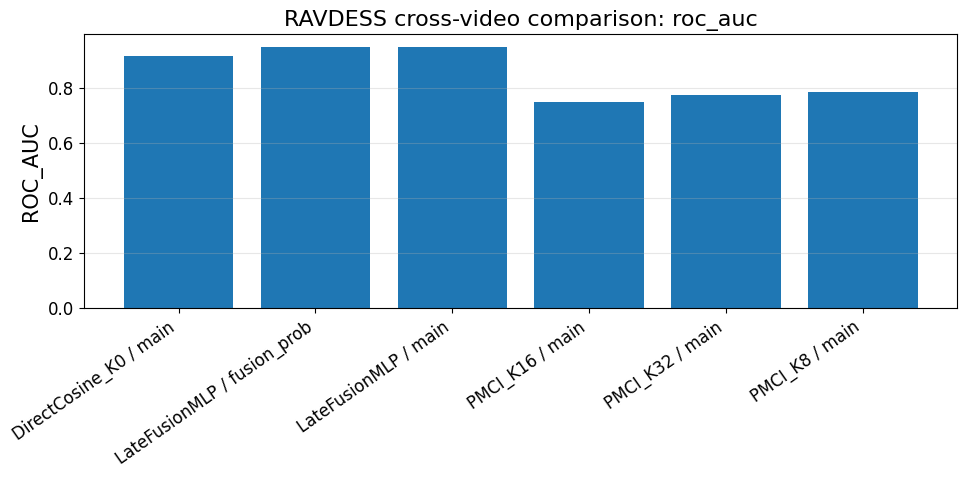

Saved figure: /content/cias_q1_min/results_q1_revision_addon/figures/fig_ravdess_cross_roc_auc_mean.png


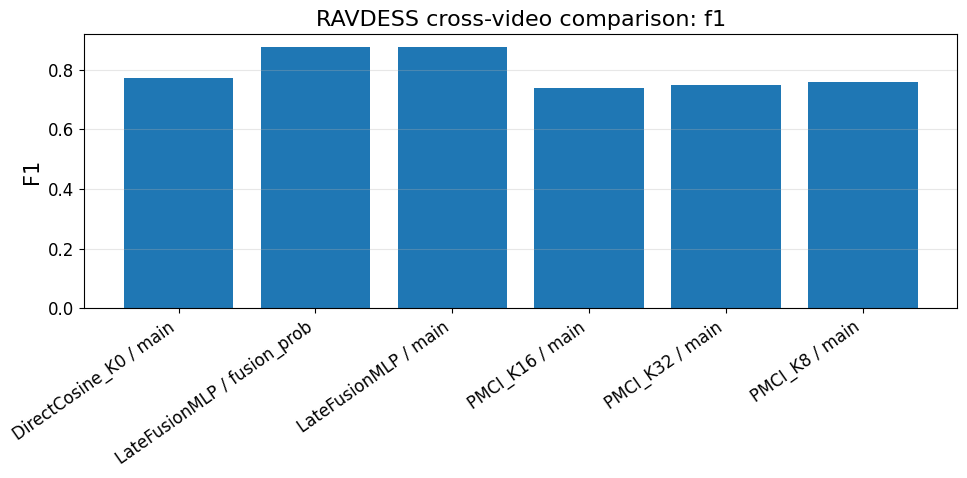

Saved figure: /content/cias_q1_min/results_q1_revision_addon/figures/fig_ravdess_cross_f1_mean.png


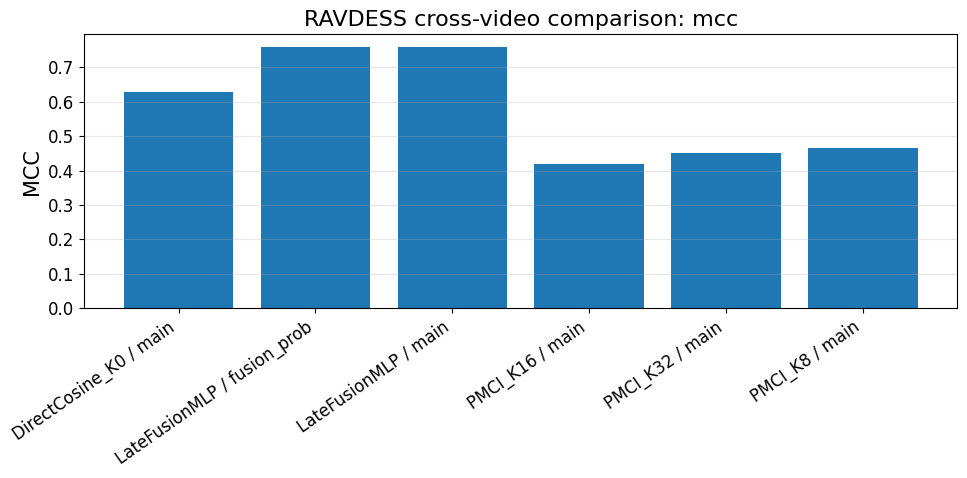

Saved figure: /content/cias_q1_min/results_q1_revision_addon/figures/fig_ravdess_cross_mcc_mean.png


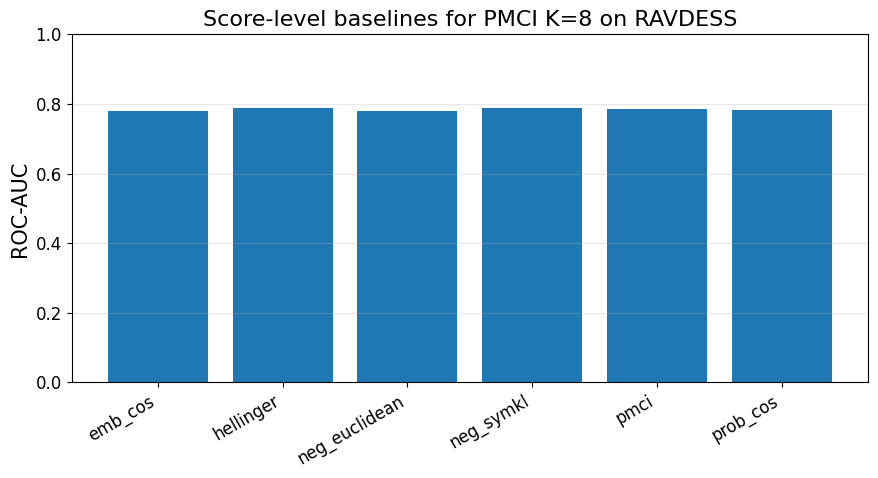

Saved figure: /content/cias_q1_min/results_q1_revision_addon/figures/fig_score_baselines_pmci_k8.png


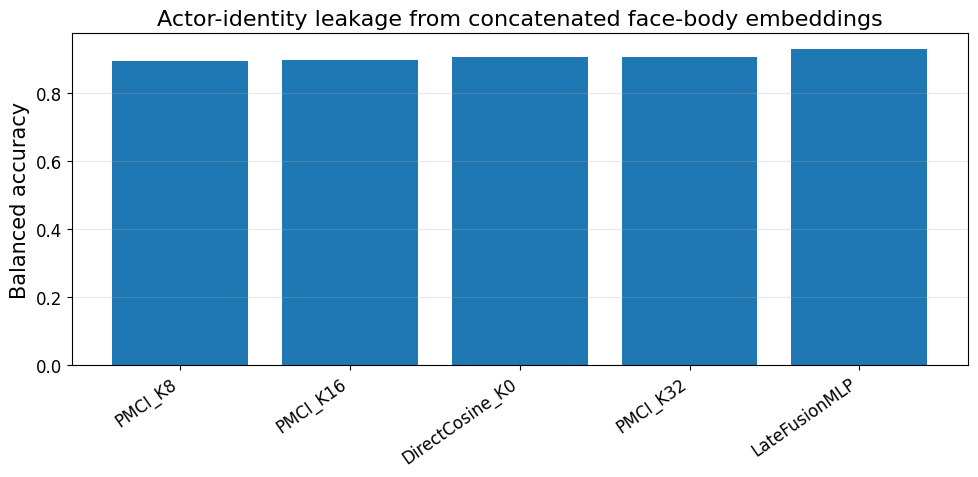

Saved figure: /content/cias_q1_min/results_q1_revision_addon/figures/fig_runtime_comparison.png

README saved: /content/cias_q1_min/results_q1_revision_addon/README_revision_addon.md

DONE.
All results saved to: /content/cias_q1_min/results_q1_revision_addon

Important files for paper revision:
- /content/cias_q1_min/results_q1_revision_addon/revision_binary_metrics_summary.csv
- /content/cias_q1_min/results_q1_revision_addon/paper_table_extended_metrics_ravdess_cross.csv
- /content/cias_q1_min/results_q1_revision_addon/paper_table_score_baselines.csv
- /content/cias_q1_min/results_q1_revision_addon/paper_table_counterfactual_key_comparison.csv
- /content/cias_q1_min/results_q1_revision_addon/revision_identity_leakage_summary.csv
- /content/cias_q1_min/results_q1_revision_addon/revision_runtime_summary.csv
- /content/cias_q1_min/results_q1_revision_addon/figures


In [ ]:

# What this code adds:
# 1) Extended binary metrics beyond ROC-AUC:
#    ROC-AUC, PR-AUC, Accuracy, Balanced Accuracy, Precision,
#    Recall, F1, MCC, Specificity, threshold.
#
# 2) Additional score baselines:
#    - embedding cosine
#    - negative Euclidean distance
#    - PMCI / negative JS divergence
#    - probability cosine
#    - negative symmetric KL
#    - Hellinger similarity
#
# 3) Additional trained baseline:
#    - Late-fusion MLP classifier:
#      input = [zF, zB, |zF-zB|, zF*zB]
#
# 4) Identity leakage for PMCI and LateFusion baseline.
#
# 5) Balanced counterfactual comparison for PMCI and baselines.
#
# 6) Runtime / parameter count.
#
# 7) Large-font figures for paper revision.
#
# Assumes shards already exist:
# /content/cias_q1_min/shards/RAVDESS/*.npz
# /content/cias_q1_min/shards/MELD/*.npz
# ============================================================

!pip -q install numpy pandas scikit-learn matplotlib tqdm

import os
import re
import gc
import time
import json
import math
import random
import warnings
import shutil
from pathlib import Path

import numpy as np
import pandas as pd
from tqdm import tqdm

import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F

from sklearn.metrics import (
    roc_auc_score,
    average_precision_score,
    accuracy_score,
    balanced_accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    matthews_corrcoef,
    confusion_matrix,
)
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

warnings.filterwarnings("ignore")

# ============================================================
# CONFIG
# ============================================================

BASE_DIR = "/content/cias_q1_min"
RAVDESS_SHARD_DIR = f"{BASE_DIR}/shards/RAVDESS"
MELD_SHARD_DIR = f"{BASE_DIR}/shards/MELD"

RESULT_DIR = f"{BASE_DIR}/results_q1_revision_addon"
FIG_DIR = f"{RESULT_DIR}/figures"
PRED_DIR = f"{RESULT_DIR}/predictions"

Path(RESULT_DIR).mkdir(parents=True, exist_ok=True)
Path(FIG_DIR).mkdir(parents=True, exist_ok=True)
Path(PRED_DIR).mkdir(parents=True, exist_ok=True)

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print("Device:", DEVICE)

SEEDS = [42, 43, 44]

# PMCI K values
K_LIST = [0, 8, 16, 32]

# Main training params
WINDOW_T = 12
FACE_DIM = 30
BODY_DIM = 72

HIDDEN_DIM = 96
EMBED_DIM = 96
TEMPERATURE = 0.25

BATCH_SIZE = 64
EPOCHS_PMCI = 7
EPOCHS_FUSION = 7
STEPS_PER_EPOCH = 60

LR_PMCI = 1e-3
LR_FUSION = 1e-3
WEIGHT_DECAY = 1e-4

# Pair evaluation
EVAL_REGIMES = ["cross", "same", "shift", "shuffle"]

# To reduce runtime if needed:
RUN_MELD_WITHIN = True
RUN_LATE_FUSION = True
RUN_COUNTERFACTUAL = False  # disabled in public paper notebook; main-run counterfactual is reported separately
RUN_IDENTITY_LEAKAGE = False  # disabled in public paper notebook; main-run identity leakage is reported separately
RUN_RUNTIME = True

# If Colab is slow, reduce this
COUNTERFACTUAL_MAX_PER_GROUP = 800

# ============================================================
# REPRODUCIBILITY
# ============================================================

def set_seed(seed: int):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.benchmark = False
    torch.backends.cudnn.deterministic = True

def clean_memory():
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()

# ============================================================
# DATA LOADING
# ============================================================

def load_shards(shard_dir, name):
    files = sorted(Path(shard_dir).glob("*.npz"))
    if not files:
        raise RuntimeError(f"No shards found in {shard_dir}")

    faces, bodies, vids, subs, dsets = [], [], [], [], []

    for fp in files:
        z = np.load(fp, allow_pickle=True)

        face_key = "face" if "face" in z.files else "faces"
        body_key = "body" if "body" in z.files else "bodies"

        faces.append(z[face_key].astype(np.float32))
        bodies.append(z[body_key].astype(np.float32))

        if "video_ids" in z.files:
            vids.append(z["video_ids"].astype(str))
        else:
            vids.append(np.array([f"{name}_{i}" for i in range(len(z[face_key]))]).astype(str))

        if "subject_ids" in z.files:
            subs.append(z["subject_ids"].astype(str))
        else:
            subs.append(np.array(["unknown"] * len(z[face_key])).astype(str))

        if "dataset" in z.files:
            dsets.append(z["dataset"].astype(str))
        else:
            dsets.append(np.array([name] * len(z[face_key])).astype(str))

    data = {
        "face": np.concatenate(faces, axis=0).astype(np.float32),
        "body": np.concatenate(bodies, axis=0).astype(np.float32),
        "video_ids": np.concatenate(vids, axis=0).astype(str),
        "subject_ids": np.concatenate(subs, axis=0).astype(str),
        "dataset": np.concatenate(dsets, axis=0).astype(str),
    }

    print(f"{name} loaded: face {data['face'].shape}, body {data['body'].shape}, videos {len(set(data['video_ids']))}")
    return data

EMOTION_MAP = {
    "01": "neutral",
    "02": "calm",
    "03": "happy",
    "04": "sad",
    "05": "angry",
    "06": "fearful",
    "07": "disgust",
    "08": "surprised",
}

def parse_ravdess_id(video_id, subject_id="unknown"):
    s = str(video_id)

    # Standard RAVDESS pattern: 03-01-05-01-02-01-12
    m = re.search(r"(\d{2})-(\d{2})-(\d{2})-(\d{2})-(\d{2})-(\d{2})-(\d{2})", s)
    if m:
        emotion_code = m.group(3)
        actor_code = m.group(7)
        return actor_code, EMOTION_MAP.get(emotion_code, "unknown")

    # fallback: try subject_id as actor
    actor = str(subject_id)
    nums = re.findall(r"\d+", s)
    emotion = "unknown"

    if len(nums) >= 7:
        emotion = EMOTION_MAP.get(nums[-5], "unknown")
        actor = nums[-1].zfill(2)

    return actor, emotion

def add_ravdess_metadata(data):
    actors = []
    emotions = []

    for vid, sid in zip(data["video_ids"], data["subject_ids"]):
        a, e = parse_ravdess_id(vid, sid)
        actors.append(a)
        emotions.append(e)

    data["actor"] = np.array(actors).astype(str)
    data["emotion"] = np.array(emotions).astype(str)
    return data

def add_meld_metadata(data):
    data["actor"] = np.array(["unknown"] * len(data["face"])).astype(str)
    data["emotion"] = np.array(["unknown"] * len(data["face"])).astype(str)
    return data

rav = add_ravdess_metadata(load_shards(RAVDESS_SHARD_DIR, "RAVDESS"))
meld = add_meld_metadata(load_shards(MELD_SHARD_DIR, "MELD"))

print("\nRAVDESS emotion distribution:")
print(pd.Series(rav["emotion"]).value_counts())

# ============================================================
# SPLITS
# ============================================================

def split_ravdess_by_actor(data):
    actors = data["actor"]

    train_actors = {str(i).zfill(2) for i in range(1, 9)}
    val_actors = {"09", "10"}
    test_actors = {"11", "12"}

    train_idx = np.where(np.isin(actors, list(train_actors)))[0]
    val_idx = np.where(np.isin(actors, list(val_actors)))[0]
    test_idx = np.where(np.isin(actors, list(test_actors)))[0]

    print("RAVDESS actor split:", len(train_idx), len(val_idx), len(test_idx))
    return train_idx, val_idx, test_idx

def split_by_video(data, seed=42, train_frac=0.70, val_frac=0.15):
    rng = np.random.default_rng(seed)
    vids = np.array(sorted(list(set(data["video_ids"]))))
    rng.shuffle(vids)

    n = len(vids)
    n_train = int(n * train_frac)
    n_val = int(n * val_frac)

    train_vids = set(vids[:n_train])
    val_vids = set(vids[n_train:n_train + n_val])
    test_vids = set(vids[n_train + n_val:])

    train_idx = np.where(np.isin(data["video_ids"], list(train_vids)))[0]
    val_idx = np.where(np.isin(data["video_ids"], list(val_vids)))[0]
    test_idx = np.where(np.isin(data["video_ids"], list(test_vids)))[0]

    print("Video split:", len(train_idx), len(val_idx), len(test_idx))
    return train_idx, val_idx, test_idx

rav_train, rav_val, rav_test = split_ravdess_by_actor(rav)
meld_train, meld_val, meld_test = split_by_video(meld, seed=42)

# ============================================================
# STANDARDIZATION
# ============================================================

def compute_standardizer(data, train_idx):
    f = data["face"][train_idx].reshape(-1, data["face"].shape[-1])
    b = data["body"][train_idx].reshape(-1, data["body"].shape[-1])

    stats = {
        "face_mean": f.mean(axis=0).astype(np.float32),
        "face_std": (f.std(axis=0) + 1e-6).astype(np.float32),
        "body_mean": b.mean(axis=0).astype(np.float32),
        "body_std": (b.std(axis=0) + 1e-6).astype(np.float32),
    }
    return stats

def apply_standardizer(data, stats):
    out = dict(data)
    out["face"] = ((data["face"] - stats["face_mean"]) / stats["face_std"]).astype(np.float32)
    out["body"] = ((data["body"] - stats["body_mean"]) / stats["body_std"]).astype(np.float32)
    return out

# Use train-only standardization per dataset
rav_stats = compute_standardizer(rav, rav_train)
meld_stats = compute_standardizer(meld, meld_train)

rav_std = apply_standardizer(rav, rav_stats)
meld_std = apply_standardizer(meld, meld_stats)

# ============================================================
# PAIR CONSTRUCTION
# ============================================================

def choose_negative_index(data, i, pool_idx, rng, regime="cross"):
    vids = data["video_ids"]
    pool_idx = np.asarray(pool_idx)

    if len(pool_idx) <= 1:
        return int(i)

    if regime == "cross":
        cand = pool_idx[vids[pool_idx] != vids[i]]
        if len(cand) == 0:
            cand = pool_idx[pool_idx != i]
        return int(rng.choice(cand))

    if regime == "same":
        cand = pool_idx[(vids[pool_idx] == vids[i]) & (pool_idx != i)]
        if len(cand) == 0:
            cand = pool_idx[pool_idx != i]
        return int(rng.choice(cand))

    if regime == "shift":
        cand = pool_idx[(vids[pool_idx] == vids[i]) & (pool_idx != i)]
        if len(cand) == 0:
            cand = pool_idx[pool_idx != i]
        return int(rng.choice(cand))

    if regime == "shuffle":
        cand = pool_idx[pool_idx != i]
        return int(rng.choice(cand))

    cand = pool_idx[pool_idx != i]
    return int(rng.choice(cand))

def sample_train_batch(data, train_idx, batch_size, rng):
    half = batch_size // 2

    pos_i = rng.choice(train_idx, size=half, replace=True)
    pos_j = pos_i.copy()

    neg_i = rng.choice(train_idx, size=batch_size - half, replace=True)
    neg_j = np.array([
        choose_negative_index(data, i, train_idx, rng, regime="cross")
        for i in neg_i
    ])

    i_all = np.concatenate([pos_i, neg_i])
    j_all = np.concatenate([pos_j, neg_j])
    y_all = np.concatenate([np.ones(half), np.zeros(batch_size - half)]).astype(np.float32)

    perm = rng.permutation(len(y_all))
    return i_all[perm], j_all[perm], y_all[perm]

def make_eval_pairs(data, idx, regime="cross", rng=None, max_pos=None):
    if rng is None:
        rng = np.random.default_rng(42)

    idx = np.asarray(idx)

    if max_pos is not None and len(idx) > max_pos:
        idx = rng.choice(idx, size=max_pos, replace=False)

    pos_i = idx.copy()
    pos_j = idx.copy()

    neg_i = idx.copy()

    if regime == "shuffle":
        neg_j = idx.copy()
        rng.shuffle(neg_j)
        for t in range(len(neg_j)):
            if neg_j[t] == neg_i[t]:
                neg_j[t] = choose_negative_index(data, neg_i[t], idx, rng, regime="cross")
    else:
        neg_j = np.array([
            choose_negative_index(data, i, idx, rng, regime=regime)
            for i in neg_i
        ])

    i_all = np.concatenate([pos_i, neg_i])
    j_all = np.concatenate([pos_j, neg_j])
    y_all = np.concatenate([np.ones(len(pos_i)), np.zeros(len(neg_i))]).astype(np.int64)

    return i_all, j_all, y_all

def get_tensors(data, i, j):
    xf = torch.tensor(data["face"][i], dtype=torch.float32, device=DEVICE)
    xb = torch.tensor(data["body"][j], dtype=torch.float32, device=DEVICE)
    return xf, xb

# ============================================================
# MODELS
# ============================================================

class DualGRUEncoder(nn.Module):
    def __init__(self, face_dim=FACE_DIM, body_dim=BODY_DIM, hidden_dim=HIDDEN_DIM, embed_dim=EMBED_DIM):
        super().__init__()
        self.face_gru = nn.GRU(face_dim, hidden_dim, batch_first=True)
        self.body_gru = nn.GRU(body_dim, hidden_dim, batch_first=True)
        self.face_proj = nn.Sequential(
            nn.Linear(hidden_dim, embed_dim),
            nn.ReLU(),
            nn.LayerNorm(embed_dim)
        )
        self.body_proj = nn.Sequential(
            nn.Linear(hidden_dim, embed_dim),
            nn.ReLU(),
            nn.LayerNorm(embed_dim)
        )

    def encode(self, xf, xb):
        _, hf = self.face_gru(xf)
        _, hb = self.body_gru(xb)

        zf = self.face_proj(hf[-1])
        zb = self.body_proj(hb[-1])

        zf = F.normalize(zf, dim=-1)
        zb = F.normalize(zb, dim=-1)

        return zf, zb

class PMCIModel(nn.Module):
    def __init__(self, k_proto=8, temperature=TEMPERATURE):
        super().__init__()
        self.k_proto = int(k_proto)
        self.temperature = temperature
        self.encoder = DualGRUEncoder()

        if self.k_proto > 0:
            self.prototypes = nn.Parameter(torch.randn(self.k_proto, EMBED_DIM) * 0.02)
        else:
            self.prototypes = None

    def forward_scores(self, xf, xb):
        zf, zb = self.encoder.encode(xf, xb)

        emb_cos = torch.sum(zf * zb, dim=-1)
        neg_euclidean = -torch.norm(zf - zb, dim=-1)

        out = {
            "emb_cos": emb_cos,
            "neg_euclidean": neg_euclidean,
            "zf": zf,
            "zb": zb,
        }

        if self.k_proto > 0:
            proto = F.normalize(self.prototypes, dim=-1)

            sf = torch.matmul(zf, proto.T) / self.temperature
            sb = torch.matmul(zb, proto.T) / self.temperature

            pf = F.softmax(sf, dim=-1)
            pb = F.softmax(sb, dim=-1)

            eps = 1e-8
            m = 0.5 * (pf + pb)

            kl_fm = torch.sum(pf * (torch.log(pf + eps) - torch.log(m + eps)), dim=-1)
            kl_bm = torch.sum(pb * (torch.log(pb + eps) - torch.log(m + eps)), dim=-1)

            # normalized JS divergence, base 2
            js = 0.5 * (kl_fm + kl_bm) / math.log(2.0)
            pmci = 1.0 - js

            kl_fb = torch.sum(pf * (torch.log(pf + eps) - torch.log(pb + eps)), dim=-1)
            kl_bf = torch.sum(pb * (torch.log(pb + eps) - torch.log(pf + eps)), dim=-1)
            sym_kl = 0.5 * (kl_fb + kl_bf)

            prob_cos = F.cosine_similarity(pf, pb, dim=-1)

            hellinger_dist = torch.sqrt(torch.sum((torch.sqrt(pf + eps) - torch.sqrt(pb + eps)) ** 2, dim=-1)) / math.sqrt(2.0)
            hellinger_sim = 1.0 - hellinger_dist

            out.update({
                "pmci": pmci,
                "neg_js": -js,
                "prob_cos": prob_cos,
                "neg_symkl": -sym_kl,
                "hellinger": hellinger_sim,
                "pf": pf,
                "pb": pb,
            })

        return out

    def main_score(self, xf, xb):
        scores = self.forward_scores(xf, xb)
        if self.k_proto == 0:
            return scores["emb_cos"]
        return scores["pmci"]

class LateFusionMLP(nn.Module):
    def __init__(self):
        super().__init__()
        self.encoder = DualGRUEncoder()
        in_dim = EMBED_DIM * 4

        self.classifier = nn.Sequential(
            nn.Linear(in_dim, 128),
            nn.ReLU(),
            nn.Dropout(0.15),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Linear(64, 1)
        )

    def forward_logits(self, xf, xb):
        zf, zb = self.encoder.encode(xf, xb)
        feat = torch.cat([zf, zb, torch.abs(zf - zb), zf * zb], dim=-1)
        logits = self.classifier(feat).squeeze(-1)
        return logits

    def forward_scores(self, xf, xb):
        zf, zb = self.encoder.encode(xf, xb)
        feat = torch.cat([zf, zb, torch.abs(zf - zb), zf * zb], dim=-1)
        logits = self.classifier(feat).squeeze(-1)
        prob = torch.sigmoid(logits)

        return {
            "fusion_prob": prob,
            "emb_cos": torch.sum(zf * zb, dim=-1),
            "neg_euclidean": -torch.norm(zf - zb, dim=-1),
            "zf": zf,
            "zb": zb,
        }

def count_params(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

# ============================================================
# TRAINING
# ============================================================

def eval_auc_for_model(model, data, idx, regime="cross", seed=42, score_name="main"):
    rng = np.random.default_rng(seed)
    i, j, y = make_eval_pairs(data, idx, regime=regime, rng=rng)

    scores = score_pairs(model, data, i, j, score_name=score_name)
    try:
        return roc_auc_score(y, scores)
    except Exception:
        return np.nan

def train_pmci_model(data, train_idx, val_idx, k_proto, seed, tag="pmci"):
    set_seed(seed)
    rng = np.random.default_rng(seed)

    model = PMCIModel(k_proto=k_proto).to(DEVICE)
    opt = torch.optim.AdamW(model.parameters(), lr=LR_PMCI, weight_decay=WEIGHT_DECAY)

    best_auc = -1
    best_state = None

    for epoch in range(1, EPOCHS_PMCI + 1):
        model.train()
        losses = []

        for _ in range(STEPS_PER_EPOCH):
            i, j, y = sample_train_batch(data, train_idx, BATCH_SIZE, rng)
            xf, xb = get_tensors(data, i, j)
            y_t = torch.tensor(y, dtype=torch.float32, device=DEVICE)

            score = model.main_score(xf, xb)

            if k_proto == 0:
                logits = 8.0 * score
            else:
                logits = 10.0 * (score - 0.5)

            loss = F.binary_cross_entropy_with_logits(logits, y_t)

            opt.zero_grad()
            loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), 5.0)
            opt.step()

            losses.append(float(loss.detach().cpu()))

        val_auc = eval_auc_for_model(model, data, val_idx, regime="cross", seed=seed + epoch, score_name="main")

        print(f"{tag} | K={k_proto} | seed={seed} | epoch {epoch:02d} | loss={np.mean(losses):.4f} | val_auc={val_auc:.4f}")

        if np.isfinite(val_auc) and val_auc > best_auc:
            best_auc = val_auc
            best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}

    if best_state is not None:
        model.load_state_dict(best_state)

    return model

def train_fusion_model(data, train_idx, val_idx, seed, tag="late_fusion"):
    set_seed(seed)
    rng = np.random.default_rng(seed)

    model = LateFusionMLP().to(DEVICE)
    opt = torch.optim.AdamW(model.parameters(), lr=LR_FUSION, weight_decay=WEIGHT_DECAY)

    best_auc = -1
    best_state = None

    for epoch in range(1, EPOCHS_FUSION + 1):
        model.train()
        losses = []

        for _ in range(STEPS_PER_EPOCH):
            i, j, y = sample_train_batch(data, train_idx, BATCH_SIZE, rng)
            xf, xb = get_tensors(data, i, j)
            y_t = torch.tensor(y, dtype=torch.float32, device=DEVICE)

            logits = model.forward_logits(xf, xb)
            loss = F.binary_cross_entropy_with_logits(logits, y_t)

            opt.zero_grad()
            loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), 5.0)
            opt.step()

            losses.append(float(loss.detach().cpu()))

        val_auc = eval_auc_for_model(model, data, val_idx, regime="cross", seed=seed + epoch, score_name="fusion_prob")

        print(f"{tag} | seed={seed} | epoch {epoch:02d} | loss={np.mean(losses):.4f} | val_auc={val_auc:.4f}")

        if np.isfinite(val_auc) and val_auc > best_auc:
            best_auc = val_auc
            best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}

    if best_state is not None:
        model.load_state_dict(best_state)

    return model

# ============================================================
# SCORING + METRICS
# ============================================================

@torch.no_grad()
def score_pairs(model, data, i, j, score_name="main", batch_size=256):
    model.eval()
    all_scores = []

    for start in range(0, len(i), batch_size):
        ii = i[start:start + batch_size]
        jj = j[start:start + batch_size]

        xf, xb = get_tensors(data, ii, jj)
        out = model.forward_scores(xf, xb)

        if score_name == "main":
            if isinstance(model, PMCIModel):
                if model.k_proto == 0:
                    s = out["emb_cos"]
                else:
                    s = out["pmci"]
            else:
                s = out["fusion_prob"]
        else:
            if score_name not in out:
                raise ValueError(f"Score {score_name} not available for model {type(model)}")
            s = out[score_name]

        all_scores.append(s.detach().cpu().numpy())

    return np.concatenate(all_scores)

def find_best_threshold(y, scores, mode="f1"):
    y = np.asarray(y).astype(int)
    scores = np.asarray(scores).astype(float)

    if len(np.unique(scores)) < 3:
        thresholds = np.linspace(scores.min() - 1e-6, scores.max() + 1e-6, 25)
    else:
        thresholds = np.quantile(scores, np.linspace(0.01, 0.99, 99))

    best_thr = float(thresholds[0])
    best_val = -1

    for thr in thresholds:
        pred = (scores >= thr).astype(int)

        if mode == "balanced_accuracy":
            val = balanced_accuracy_score(y, pred)
        else:
            val = f1_score(y, pred, zero_division=0)

        if val > best_val:
            best_val = val
            best_thr = float(thr)

    return best_thr

def compute_binary_metrics(y, scores, threshold):
    y = np.asarray(y).astype(int)
    scores = np.asarray(scores).astype(float)
    pred = (scores >= threshold).astype(int)

    out = {}

    try:
        out["roc_auc"] = roc_auc_score(y, scores)
    except Exception:
        out["roc_auc"] = np.nan

    try:
        out["pr_auc"] = average_precision_score(y, scores)
    except Exception:
        out["pr_auc"] = np.nan

    out["accuracy"] = accuracy_score(y, pred)
    out["balanced_accuracy"] = balanced_accuracy_score(y, pred)
    out["precision"] = precision_score(y, pred, zero_division=0)
    out["recall"] = recall_score(y, pred, zero_division=0)
    out["f1"] = f1_score(y, pred, zero_division=0)

    try:
        out["mcc"] = matthews_corrcoef(y, pred)
    except Exception:
        out["mcc"] = np.nan

    try:
        tn, fp, fn, tp = confusion_matrix(y, pred, labels=[0, 1]).ravel()
        out["specificity"] = tn / (tn + fp + 1e-8)
    except Exception:
        out["specificity"] = np.nan

    out["threshold"] = threshold
    out["n"] = len(y)
    out["pos_rate"] = float(np.mean(y))

    return out

def evaluate_model_on_regimes(model, data, val_idx, test_idx, dataset_name, model_name, seed, score_names):
    rows = []
    pred_rows = []

    for regime in EVAL_REGIMES:
        rng_val = np.random.default_rng(seed + 1000)
        rng_test = np.random.default_rng(seed + 2000)

        vi, vj, vy = make_eval_pairs(data, val_idx, regime=regime, rng=rng_val)
        ti, tj, ty = make_eval_pairs(data, test_idx, regime=regime, rng=rng_test)

        for score_name in score_names:
            try:
                val_scores = score_pairs(model, data, vi, vj, score_name=score_name)
                test_scores = score_pairs(model, data, ti, tj, score_name=score_name)
            except Exception:
                continue

            thr = find_best_threshold(vy, val_scores, mode="f1")
            metrics = compute_binary_metrics(ty, test_scores, thr)

            row = {
                "dataset": dataset_name,
                "model": model_name,
                "seed": seed,
                "regime": regime,
                "score_name": score_name,
            }
            row.update(metrics)
            rows.append(row)

            # Save prediction-level rows
            for a, b, label, score in zip(ti, tj, ty, test_scores):
                pred_rows.append({
                    "dataset": dataset_name,
                    "model": model_name,
                    "seed": seed,
                    "regime": regime,
                    "score_name": score_name,
                    "face_index": int(a),
                    "body_index": int(b),
                    "label": int(label),
                    "score": float(score),
                    "threshold": float(thr),
                })

    return rows, pred_rows

# ============================================================
# IDENTITY LEAKAGE
# ============================================================

@torch.no_grad()
def extract_embeddings(model, data, idx, batch_size=256):
    model.eval()

    zf_all = []
    zb_all = []

    for start in range(0, len(idx), batch_size):
        ii = idx[start:start + batch_size]
        xf = torch.tensor(data["face"][ii], dtype=torch.float32, device=DEVICE)
        xb = torch.tensor(data["body"][ii], dtype=torch.float32, device=DEVICE)

        if isinstance(model, PMCIModel):
            zf, zb = model.encoder.encode(xf, xb)
        else:
            zf, zb = model.encoder.encode(xf, xb)

        zf_all.append(zf.detach().cpu().numpy())
        zb_all.append(zb.detach().cpu().numpy())

    zf_all = np.concatenate(zf_all, axis=0)
    zb_all = np.concatenate(zb_all, axis=0)

    return zf_all, zb_all

def identity_leakage_eval(model, data, model_name, seed):
    idx = np.arange(len(data["face"]))
    actors = data["actor"].astype(str)

    valid = actors != "unknown"
    idx = idx[valid]
    actors = actors[valid]

    zf, zb = extract_embeddings(model, data, idx)
    feats = {
        "face_embedding": zf,
        "body_embedding": zb,
        "concat_face_body": np.concatenate([zf, zb], axis=1),
    }

    rows = []

    for emb_name, X in feats.items():
        y = actors

        tr, te = train_test_split(
            np.arange(len(y)),
            test_size=0.35,
            random_state=seed,
            stratify=y
        )

        scaler = StandardScaler()
        Xtr = scaler.fit_transform(X[tr])
        Xte = scaler.transform(X[te])

        clf = LogisticRegression(
            max_iter=2000,
            class_weight="balanced",
            multi_class="auto",
            n_jobs=-1
        )
        clf.fit(Xtr, y[tr])
        pred = clf.predict(Xte)

        rows.append({
            "model": model_name,
            "seed": seed,
            "embedding": emb_name,
            "accuracy": accuracy_score(y[te], pred),
            "balanced_accuracy": balanced_accuracy_score(y[te], pred),
            "n_classes": len(np.unique(y)),
            "n_samples": len(y),
        })

    return rows

# ============================================================
# COUNTERFACTUAL PAIRS
# ============================================================

def sample_pair_type(data, indices, pair_type, rng, max_pairs=800):
    indices = np.asarray(indices)
    actors = data["actor"]
    emotions = data["emotion"]

    pairs = []

    for i in indices:
        if pair_type == "true_pair":
            pairs.append((i, i))
            continue

        if pair_type == "random_mismatch":
            cand = indices[indices != i]

        elif pair_type == "same_emotion_diff_actor":
            cand = indices[(emotions[indices] == emotions[i]) & (actors[indices] != actors[i])]

        elif pair_type == "same_actor_diff_emotion":
            cand = indices[(actors[indices] == actors[i]) & (emotions[indices] != emotions[i])]

        elif pair_type == "diff_emotion_diff_actor":
            cand = indices[(emotions[indices] != emotions[i]) & (actors[indices] != actors[i])]

        else:
            raise ValueError(pair_type)

        cand = cand[cand != i]

        if len(cand) == 0:
            continue

        j = int(rng.choice(cand))
        pairs.append((int(i), j))

        if len(pairs) >= max_pairs:
            break

    return pairs

def counterfactual_eval(model, data, indices, model_name, seed, score_name="main"):
    rng = np.random.default_rng(seed)

    comparisons = [
        ("same_emotion_diff_actor", "diff_emotion_diff_actor"),
        ("same_emotion_diff_actor", "same_actor_diff_emotion"),
        ("true_pair", "random_mismatch"),
        ("true_pair", "same_actor_diff_emotion"),
    ]

    rows = []

    for pos_type, neg_type in comparisons:
        pos_pairs = sample_pair_type(data, indices, pos_type, rng, max_pairs=COUNTERFACTUAL_MAX_PER_GROUP)
        neg_pairs = sample_pair_type(data, indices, neg_type, rng, max_pairs=COUNTERFACTUAL_MAX_PER_GROUP)

        n = min(len(pos_pairs), len(neg_pairs))

        if n < 10:
            continue

        pos_pairs = pos_pairs[:n]
        neg_pairs = neg_pairs[:n]

        i = np.array([p[0] for p in pos_pairs + neg_pairs])
        j = np.array([p[1] for p in pos_pairs + neg_pairs])
        y = np.array([1] * n + [0] * n)

        scores = score_pairs(model, data, i, j, score_name=score_name)

        thr = find_best_threshold(y, scores, mode="f1")
        metrics = compute_binary_metrics(y, scores, thr)

        row = {
            "model": model_name,
            "seed": seed,
            "score_name": score_name,
            "comparison": f"{pos_type}_vs_{neg_type}",
            "positive_type": pos_type,
            "negative_type": neg_type,
        }
        row.update(metrics)
        rows.append(row)

    return rows

# ============================================================
# RUNTIME
# ============================================================

@torch.no_grad()
def runtime_eval(model, data, idx, model_name, seed, n_batches=30, batch_size=64):
    model.eval()
    rng = np.random.default_rng(seed)

    if len(idx) < batch_size:
        return []

    # warmup
    for _ in range(5):
        ii = rng.choice(idx, size=batch_size, replace=True)
        jj = rng.choice(idx, size=batch_size, replace=True)
        xf, xb = get_tensors(data, ii, jj)
        _ = model.forward_scores(xf, xb)

    if torch.cuda.is_available():
        torch.cuda.synchronize()

    times = []
    for _ in range(n_batches):
        ii = rng.choice(idx, size=batch_size, replace=True)
        jj = rng.choice(idx, size=batch_size, replace=True)
        xf, xb = get_tensors(data, ii, jj)

        t0 = time.time()
        _ = model.forward_scores(xf, xb)

        if torch.cuda.is_available():
            torch.cuda.synchronize()

        t1 = time.time()
        times.append(t1 - t0)

    return [{
        "model": model_name,
        "seed": seed,
        "params": count_params(model),
        "batch_size": batch_size,
        "mean_batch_time_sec": float(np.mean(times)),
        "std_batch_time_sec": float(np.std(times)),
        "mean_window_time_ms": float(np.mean(times) / batch_size * 1000.0),
        "device": DEVICE,
    }]

# ============================================================
# MAIN EXPERIMENT LOOP
# ============================================================

all_metric_rows = []
all_pred_rows = []
all_identity_rows = []
all_counter_rows = []
all_runtime_rows = []

trained_models = {}

for seed in SEEDS:
    print("\n" + "#" * 100)
    print("SEED:", seed)
    print("#" * 100)

    # --------------------------------------------------------
    # RAVDESS PMCI / Direct cosine models
    # --------------------------------------------------------
    for k in K_LIST:
        print("\n" + "=" * 80)
        print(f"TRAIN RAVDESS PMCI / DIRECT | seed={seed} | K={k}")
        print("=" * 80)

        model_name = f"DirectCosine_K0" if k == 0 else f"PMCI_K{k}"

        model = train_pmci_model(
            data=rav_std,
            train_idx=rav_train,
            val_idx=rav_val,
            k_proto=k,
            seed=seed,
            tag="ravdess_pmci"
        )

        trained_models[(seed, model_name)] = model

        if k == 0:
            score_names = ["main", "emb_cos", "neg_euclidean"]
        else:
            score_names = ["main", "pmci", "emb_cos", "neg_euclidean", "prob_cos", "neg_symkl", "hellinger"]

        rows, preds = evaluate_model_on_regimes(
            model=model,
            data=rav_std,
            val_idx=rav_val,
            test_idx=rav_test,
            dataset_name="RAVDESS",
            model_name=model_name,
            seed=seed,
            score_names=score_names
        )

        all_metric_rows.extend(rows)
        all_pred_rows.extend(preds)

        if RUN_IDENTITY_LEAKAGE:
            all_identity_rows.extend(identity_leakage_eval(model, rav_std, model_name, seed))

        if RUN_COUNTERFACTUAL:
            # Use all RAVDESS for richer balanced counterfactual sampling
            cf_indices = np.arange(len(rav_std["face"]))
            for sname in score_names:
                try:
                    all_counter_rows.extend(counterfactual_eval(model, rav_std, cf_indices, model_name, seed, score_name=sname))
                except Exception:
                    pass

        if RUN_RUNTIME:
            all_runtime_rows.extend(runtime_eval(model, rav_std, rav_test, model_name, seed))

        clean_memory()

    # --------------------------------------------------------
    # RAVDESS Late Fusion MLP baseline
    # --------------------------------------------------------
    if RUN_LATE_FUSION:
        print("\n" + "=" * 80)
        print(f"TRAIN RAVDESS LATE-FUSION MLP | seed={seed}")
        print("=" * 80)

        fusion_model = train_fusion_model(
            data=rav_std,
            train_idx=rav_train,
            val_idx=rav_val,
            seed=seed,
            tag="ravdess_late_fusion"
        )

        model_name = "LateFusionMLP"

        rows, preds = evaluate_model_on_regimes(
            model=fusion_model,
            data=rav_std,
            val_idx=rav_val,
            test_idx=rav_test,
            dataset_name="RAVDESS",
            model_name=model_name,
            seed=seed,
            score_names=["main", "fusion_prob", "emb_cos", "neg_euclidean"]
        )

        all_metric_rows.extend(rows)
        all_pred_rows.extend(preds)

        if RUN_IDENTITY_LEAKAGE:
            all_identity_rows.extend(identity_leakage_eval(fusion_model, rav_std, model_name, seed))

        if RUN_COUNTERFACTUAL:
            cf_indices = np.arange(len(rav_std["face"]))
            for sname in ["main", "fusion_prob", "emb_cos", "neg_euclidean"]:
                try:
                    all_counter_rows.extend(counterfactual_eval(fusion_model, rav_std, cf_indices, model_name, seed, score_name=sname))
                except Exception:
                    pass

        if RUN_RUNTIME:
            all_runtime_rows.extend(runtime_eval(fusion_model, rav_std, rav_test, model_name, seed))

        clean_memory()

    # --------------------------------------------------------
    # MELD within PMCI K=8
    # --------------------------------------------------------
    if RUN_MELD_WITHIN:
        print("\n" + "=" * 80)
        print(f"TRAIN MELD WITHIN PMCI K=8 | seed={seed}")
        print("=" * 80)

        meld_model = train_pmci_model(
            data=meld_std,
            train_idx=meld_train,
            val_idx=meld_val,
            k_proto=8,
            seed=seed,
            tag="meld_pmci"
        )

        model_name = "PMCI_K8_MELD"

        rows, preds = evaluate_model_on_regimes(
            model=meld_model,
            data=meld_std,
            val_idx=meld_val,
            test_idx=meld_test,
            dataset_name="MELD",
            model_name=model_name,
            seed=seed,
            score_names=["main", "pmci", "emb_cos", "neg_euclidean", "prob_cos", "neg_symkl", "hellinger"]
        )

        all_metric_rows.extend(rows)
        all_pred_rows.extend(preds)

        if RUN_RUNTIME:
            all_runtime_rows.extend(runtime_eval(meld_model, meld_std, meld_test, model_name, seed))

        clean_memory()

# ============================================================
# SAVE RAW RESULTS
# ============================================================

metrics_df = pd.DataFrame(all_metric_rows)
pred_df = pd.DataFrame(all_pred_rows)
identity_df = pd.DataFrame(all_identity_rows)
counter_df = pd.DataFrame(all_counter_rows)
runtime_df = pd.DataFrame(all_runtime_rows)

metrics_path = f"{RESULT_DIR}/revision_binary_metrics_all.csv"
pred_path = f"{RESULT_DIR}/revision_prediction_level_scores.csv"
identity_path = f"{RESULT_DIR}/revision_identity_leakage_extended.csv"
counter_path = f"{RESULT_DIR}/revision_counterfactual_extended.csv"
runtime_path = f"{RESULT_DIR}/revision_runtime_params.csv"

metrics_df.to_csv(metrics_path, index=False)
pred_df.to_csv(pred_path, index=False)
identity_df.to_csv(identity_path, index=False)
counter_df.to_csv(counter_path, index=False)
runtime_df.to_csv(runtime_path, index=False)

print("\nSaved:")
print(metrics_path)
print(pred_path)
print(identity_path)
print(counter_path)
print(runtime_path)

# ============================================================
# SUMMARIES
# ============================================================

def summarize_mean_std(df, group_cols, metric_cols):
    rows = []
    for keys, g in df.groupby(group_cols):
        if not isinstance(keys, tuple):
            keys = (keys,)

        row = {c: v for c, v in zip(group_cols, keys)}

        for m in metric_cols:
            row[f"{m}_mean"] = g[m].mean()
            row[f"{m}_std"] = g[m].std(ddof=0)

        rows.append(row)

    return pd.DataFrame(rows)

metric_cols = [
    "roc_auc", "pr_auc", "accuracy", "balanced_accuracy",
    "precision", "recall", "f1", "mcc", "specificity"
]

summary_df = summarize_mean_std(
    metrics_df,
    group_cols=["dataset", "model", "regime", "score_name"],
    metric_cols=metric_cols
)

summary_path = f"{RESULT_DIR}/revision_binary_metrics_summary.csv"
summary_df.to_csv(summary_path, index=False)

identity_summary = summarize_mean_std(
    identity_df,
    group_cols=["model", "embedding"],
    metric_cols=["accuracy", "balanced_accuracy"]
) if len(identity_df) else pd.DataFrame()

identity_summary_path = f"{RESULT_DIR}/revision_identity_leakage_summary.csv"
identity_summary.to_csv(identity_summary_path, index=False)

counter_summary = summarize_mean_std(
    counter_df,
    group_cols=["model", "score_name", "comparison"],
    metric_cols=metric_cols
) if len(counter_df) else pd.DataFrame()

counter_summary_path = f"{RESULT_DIR}/revision_counterfactual_summary.csv"
counter_summary.to_csv(counter_summary_path, index=False)

runtime_summary = summarize_mean_std(
    runtime_df,
    group_cols=["model"],
    metric_cols=["params", "mean_window_time_ms"]
) if len(runtime_df) else pd.DataFrame()

runtime_summary_path = f"{RESULT_DIR}/revision_runtime_summary.csv"
runtime_summary.to_csv(runtime_summary_path, index=False)

print("\nSummary files:")
print(summary_path)
print(identity_summary_path)
print(counter_summary_path)
print(runtime_summary_path)

print("\nBINARY METRICS SUMMARY HEAD:")
display(summary_df.head(30))

print("\nIDENTITY SUMMARY:")
display(identity_summary)

print("\nCOUNTERFACTUAL SUMMARY HEAD:")
display(counter_summary.head(30))

print("\nRUNTIME SUMMARY:")
display(runtime_summary)

# ============================================================
# PAPER-READY TABLES
# ============================================================

# Main comparison table: RAVDESS cross, main score only
paper_main = summary_df[
    (summary_df["dataset"] == "RAVDESS") &
    (summary_df["regime"] == "cross") &
    (summary_df["score_name"].isin(["main", "fusion_prob"]))
].copy()

paper_main = paper_main.sort_values(["model", "score_name"])

paper_main_path = f"{RESULT_DIR}/paper_table_extended_metrics_ravdess_cross.csv"
paper_main.to_csv(paper_main_path, index=False)

# Score baseline table: RAVDESS, PMCI K=8/16/32, cross
paper_score_baselines = summary_df[
    (summary_df["dataset"] == "RAVDESS") &
    (summary_df["regime"] == "cross") &
    (summary_df["model"].str.contains("PMCI")) &
    (summary_df["score_name"].isin(["pmci", "emb_cos", "neg_euclidean", "prob_cos", "neg_symkl", "hellinger"]))
].copy()

paper_score_baselines_path = f"{RESULT_DIR}/paper_table_score_baselines.csv"
paper_score_baselines.to_csv(paper_score_baselines_path, index=False)

# Counterfactual key table
key_comp = "same_emotion_diff_actor_vs_same_actor_diff_emotion"
paper_counter = counter_summary[
    counter_summary["comparison"] == key_comp
].copy()

paper_counter_path = f"{RESULT_DIR}/paper_table_counterfactual_key_comparison.csv"
paper_counter.to_csv(paper_counter_path, index=False)

print("\nPaper-ready tables:")
print(paper_main_path)
print(paper_score_baselines_path)
print(paper_counter_path)

# ============================================================
# LARGE FONT FIGURES
# ============================================================

plt.rcParams.update({
    "font.size": 14,
    "axes.titlesize": 16,
    "axes.labelsize": 15,
    "legend.fontsize": 12,
    "xtick.labelsize": 12,
    "ytick.labelsize": 12,
})

def savefig(path):
    plt.tight_layout()
    plt.savefig(path, dpi=300, bbox_inches="tight")
    plt.show()
    print("Saved figure:", path)

# Figure 1: RAVDESS cross ROC-AUC / F1 / MCC main comparison
fig_data = paper_main.copy()
if len(fig_data):
    labels = fig_data["model"] + " / " + fig_data["score_name"]
    x = np.arange(len(labels))

    for metric in ["roc_auc_mean", "f1_mean", "mcc_mean"]:
        plt.figure(figsize=(10, 5))
        plt.bar(x, fig_data[metric].values)
        plt.xticks(x, labels, rotation=35, ha="right")
        plt.ylabel(metric.replace("_mean", "").upper())
        plt.title(f"RAVDESS cross-video comparison: {metric.replace('_mean', '')}")
        plt.grid(axis="y", alpha=0.3)
        savefig(f"{FIG_DIR}/fig_ravdess_cross_{metric}.png")

# Figure 2: Score baselines for PMCI K=8
fig_data = paper_score_baselines[paper_score_baselines["model"] == "PMCI_K8"].copy()
if len(fig_data):
    plt.figure(figsize=(9, 5))
    labels = fig_data["score_name"].values
    x = np.arange(len(labels))
    plt.bar(x, fig_data["roc_auc_mean"].values)
    plt.xticks(x, labels, rotation=30, ha="right")
    plt.ylabel("ROC-AUC")
    plt.title("Score-level baselines for PMCI K=8 on RAVDESS")
    plt.ylim(0.0, 1.0)
    plt.grid(axis="y", alpha=0.3)
    savefig(f"{FIG_DIR}/fig_score_baselines_pmci_k8.png")

# Figure 3: Identity leakage (not included in public paper notebook; main-run identity table is used)
if False and len(identity_summary):
    fig_data = identity_summary[identity_summary["embedding"] == "concat_face_body"].copy()
    fig_data = fig_data.sort_values("balanced_accuracy_mean")

    plt.figure(figsize=(10, 5))
    x = np.arange(len(fig_data))
    plt.bar(x, fig_data["balanced_accuracy_mean"].values)
    plt.xticks(x, fig_data["model"].values, rotation=35, ha="right")
    plt.ylabel("Balanced accuracy")
    plt.title("Actor-identity leakage from concatenated face-body embeddings")
    plt.grid(axis="y", alpha=0.3)
    savefig(f"{FIG_DIR}/fig_identity_leakage_extended.png")

# Figure 4: Key counterfactual comparison (not included in public paper notebook; main-run counterfactual table is used)
if False and len(paper_counter):
    fig_data = paper_counter.copy()
    fig_data = fig_data.sort_values("roc_auc_mean")

    labels = fig_data["model"] + " / " + fig_data["score_name"]
    x = np.arange(len(labels))

    plt.figure(figsize=(12, 5))
    plt.bar(x, fig_data["roc_auc_mean"].values)
    plt.axhline(0.5, linestyle="--")
    plt.xticks(x, labels, rotation=40, ha="right")
    plt.ylabel("ROC-AUC")
    plt.title("Identity-emotion conflict: same-emotion/different-actor vs same-actor/different-emotion")
    plt.grid(axis="y", alpha=0.3)
    savefig(f"{FIG_DIR}/fig_counterfactual_identity_emotion_conflict.png")

# Figure 5: Runtime
if len(runtime_summary):
    fig_data = runtime_summary.sort_values("mean_window_time_ms_mean")

    plt.figure(figsize=(10, 5))
    x = np.arange(len(fig_data))
    plt.bar(x, fig_data["mean_window_time_ms_mean"].values)
    plt.xticks(x, fig_data["model"].values, rotation=35, ha="right")
    plt.ylabel("Mean inference time per window (ms)")
    plt.title("Runtime comparison")
    plt.grid(axis="y", alpha=0.3)
    savefig(f"{FIG_DIR}/fig_runtime_comparison.png")

# ============================================================
# README FOR REPOSITORY
# ============================================================

readme = f"""
# PMCI Add-on Experiments

This folder contains reviewer-revision experiments for the paper:
"Probabilistic Multimodal Consistency of Facial and Gestural Affective Cues in Interactive Systems".

## Data used
- RAVDESS shards: {RAVDESS_SHARD_DIR}
- MELD shards: {MELD_SHARD_DIR}

## Shard shapes observed
- RAVDESS face: {rav['face'].shape}
- RAVDESS body: {rav['body'].shape}
- MELD face: {meld['face'].shape}
- MELD body: {meld['body'].shape}

## Seeds
{SEEDS}

## Added experiments
1. Extended binary metrics:
   ROC-AUC, PR-AUC, accuracy, balanced accuracy, precision, recall, F1, MCC, specificity.

2. Additional score baselines:
   embedding cosine, negative Euclidean distance, PMCI / negative JS divergence,
   probability cosine, negative symmetric KL, Hellinger similarity.

3. Additional trained baseline:
   Late-fusion MLP using [zF, zB, |zF-zB|, zF*zB].

4. Identity leakage:
   Linear actor classifier on face, body, and concatenated embeddings.

5. Balanced counterfactual evaluation:
   same-emotion/different-actor vs same-actor/different-emotion and related controls.

6. Runtime and parameter count.

## Output files
- revision_binary_metrics_all.csv
- revision_binary_metrics_summary.csv
- revision_prediction_level_scores.csv
- revision_identity_leakage_extended.csv
- revision_identity_leakage_summary.csv
- revision_counterfactual_extended.csv
- revision_counterfactual_summary.csv
- revision_runtime_params.csv
- revision_runtime_summary.csv
- paper_table_extended_metrics_ravdess_cross.csv
- paper_table_score_baselines.csv
- paper_table_counterfactual_key_comparison.csv
- figures/*.png
"""

readme_path = f"{RESULT_DIR}/README_revision_addon.md"
Path(readme_path).write_text(readme)

print("\nREADME saved:", readme_path)

# ============================================================
# FINAL CHECK
# ============================================================

print("\nDONE.")
print("All results saved to:", RESULT_DIR)
print("\nImportant files for paper revision:")
print("-", summary_path)
print("-", paper_main_path)
print("-", paper_score_baselines_path)
print("-", paper_counter_path)
print("-", identity_summary_path)
print("-", runtime_summary_path)
print("-", FIG_DIR)

**Note.** Extended identity-leakage and counterfactual outputs from a retrained add-on baseline were excluded from the public paper notebook to avoid mixing protocols. The manuscript uses the main-run identity-leakage and balanced-counterfactual analyses.


## Original cell 27: SAFE ADDITIONAL ANALYSIS 


In [ ]:
# ============================================================
# SAFE ADDITIONAL ANALYSIS 
# ============================================================
# Uses already generated CSV files.
# Does NOT retrain models.
#
# Produces:
# 1) bootstrap confidence intervals
# 2) paired model comparisons
# 3) modality-collapse index
# 4) adaptation gain table
# 5) counterfactual advantage table
# 6) paper-ready figures
# ============================================================

!pip -q install numpy pandas scikit-learn matplotlib scipy

import os
import re
import json
import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from pathlib import Path
from sklearn.metrics import (
    roc_auc_score,
    average_precision_score,
    accuracy_score,
    balanced_accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    matthews_corrcoef,
    confusion_matrix,
)
from scipy.stats import ttest_rel, wilcoxon

# ============================================================
# PATHS
# ============================================================

BASE_DIR = "/content/cias_q1_min"

MAIN_DIR = f"{BASE_DIR}/results_q1_criticism_suite"
ADDON_DIR = f"{BASE_DIR}/results_q1_revision_addon"

OUT_DIR = f"{BASE_DIR}/results_q1_final_extra_evidence"
FIG_DIR = f"{OUT_DIR}/figures"

Path(OUT_DIR).mkdir(parents=True, exist_ok=True)
Path(FIG_DIR).mkdir(parents=True, exist_ok=True)

print("MAIN_DIR:", MAIN_DIR)
print("ADDON_DIR:", ADDON_DIR)
print("OUT_DIR:", OUT_DIR)

# ============================================================
# LOAD FILES
# ============================================================

def must_read_csv(path):
    if not Path(path).exists():
        raise FileNotFoundError(f"Missing file: {path}")
    print("Loaded:", path)
    return pd.read_csv(path)

main_csv = must_read_csv(f"{MAIN_DIR}/main_multiseed_results.csv")
drop_csv = must_read_csv(f"{MAIN_DIR}/modality_dropout_controls.csv")
id_csv = must_read_csv(f"{MAIN_DIR}/identity_leakage_classifier.csv")
cf_csv = must_read_csv(f"{MAIN_DIR}/balanced_counterfactual_results.csv")

metrics_csv = must_read_csv(f"{ADDON_DIR}/revision_binary_metrics_summary.csv")
pred_csv = must_read_csv(f"{ADDON_DIR}/revision_prediction_level_scores.csv")
runtime_csv = must_read_csv(f"{ADDON_DIR}/revision_runtime_summary.csv")

print("\nmain_csv columns:", list(main_csv.columns))
print("drop_csv columns:", list(drop_csv.columns))
print("id_csv columns:", list(id_csv.columns))
print("cf_csv columns:", list(cf_csv.columns))
print("metrics_csv columns:", list(metrics_csv.columns))
print("pred_csv columns:", list(pred_csv.columns))

# ============================================================
# HELPER METRICS
# ============================================================

def fixed_threshold_from_group(df):
    if "threshold" in df.columns:
        vals = df["threshold"].dropna().values
        if len(vals) > 0:
            return float(np.median(vals))
    return float(np.median(df["score"].values))

def compute_metrics(y, scores, threshold=None):
    y = np.asarray(y).astype(int)
    scores = np.asarray(scores).astype(float)

    if threshold is None:
        threshold = np.median(scores)

    pred = (scores >= threshold).astype(int)

    out = {}

    try:
        out["roc_auc"] = roc_auc_score(y, scores)
    except:
        out["roc_auc"] = np.nan

    try:
        out["pr_auc"] = average_precision_score(y, scores)
    except:
        out["pr_auc"] = np.nan

    out["accuracy"] = accuracy_score(y, pred)
    out["balanced_accuracy"] = balanced_accuracy_score(y, pred)
    out["precision"] = precision_score(y, pred, zero_division=0)
    out["recall"] = recall_score(y, pred, zero_division=0)
    out["f1"] = f1_score(y, pred, zero_division=0)

    try:
        out["mcc"] = matthews_corrcoef(y, pred)
    except:
        out["mcc"] = np.nan

    try:
        tn, fp, fn, tp = confusion_matrix(y, pred, labels=[0, 1]).ravel()
        out["specificity"] = tn / (tn + fp + 1e-8)
    except:
        out["specificity"] = np.nan

    out["threshold"] = threshold
    out["n"] = len(y)
    return out

def bootstrap_ci_for_group(df, n_boot=1000, seed=42):
    rng = np.random.default_rng(seed)
    y = df["label"].values.astype(int)
    scores = df["score"].values.astype(float)
    threshold = fixed_threshold_from_group(df)

    base = compute_metrics(y, scores, threshold)

    rows = []
    n = len(df)

    for _ in range(n_boot):
        idx = rng.choice(np.arange(n), size=n, replace=True)
        yy = y[idx]
        ss = scores[idx]

        if len(np.unique(yy)) < 2:
            continue

        rows.append(compute_metrics(yy, ss, threshold))

    bdf = pd.DataFrame(rows)

    result = dict(base)

    for col in ["roc_auc", "pr_auc", "accuracy", "balanced_accuracy", "precision", "recall", "f1", "mcc", "specificity"]:
        vals = bdf[col].dropna().values
        if len(vals) == 0:
            result[col + "_ci_low"] = np.nan
            result[col + "_ci_high"] = np.nan
        else:
            result[col + "_ci_low"] = np.percentile(vals, 2.5)
            result[col + "_ci_high"] = np.percentile(vals, 97.5)

    return result

# ============================================================
# EXPERIMENT 1: BOOTSTRAP CI FOR MAIN MODELS
# ============================================================

selected_models = [
    "DirectCosine_K0",
    "LateFusionMLP",
    "PMCI_K8",
    "PMCI_K16",
    "PMCI_K32",
]

selected_scores = {
    "DirectCosine_K0": ["main"],
    "LateFusionMLP": ["main"],
    "PMCI_K8": ["main", "emb_cos", "prob_cos", "neg_symkl", "hellinger"],
    "PMCI_K16": ["main"],
    "PMCI_K32": ["main"],
}

bootstrap_rows = []

for dataset in ["RAVDESS", "MELD"]:
    for regime in ["cross", "same", "shift", "shuffle"]:
        for model in selected_models:
            for score_name in selected_scores.get(model, ["main"]):

                g = pred_csv[
                    (pred_csv["dataset"] == dataset) &
                    (pred_csv["regime"] == regime) &
                    (pred_csv["model"] == model) &
                    (pred_csv["score_name"] == score_name)
                ].copy()

                if len(g) < 20:
                    continue

                res = bootstrap_ci_for_group(g, n_boot=1000, seed=42)
                res.update({
                    "dataset": dataset,
                    "regime": regime,
                    "model": model,
                    "score_name": score_name,
                })
                bootstrap_rows.append(res)

bootstrap_df = pd.DataFrame(bootstrap_rows)
bootstrap_path = f"{OUT_DIR}/extra_bootstrap_ci_metrics.csv"
bootstrap_df.to_csv(bootstrap_path, index=False)

print("\nSaved bootstrap CI:", bootstrap_path)
display(bootstrap_df.head(20))

# ============================================================
# EXPERIMENT 2: PAIRED MODEL COMPARISONS
# ============================================================

def paired_auc_delta(pred_df, dataset, regime, model_a, score_a, model_b, score_b, n_boot=1000, seed=42):
    rows = []
    rng = np.random.default_rng(seed)

    for s in sorted(pred_df["seed"].unique()):
        A = pred_df[
            (pred_df["dataset"] == dataset) &
            (pred_df["regime"] == regime) &
            (pred_df["model"] == model_a) &
            (pred_df["score_name"] == score_a) &
            (pred_df["seed"] == s)
        ].copy()

        B = pred_df[
            (pred_df["dataset"] == dataset) &
            (pred_df["regime"] == regime) &
            (pred_df["model"] == model_b) &
            (pred_df["score_name"] == score_b) &
            (pred_df["seed"] == s)
        ].copy()

        if len(A) == 0 or len(B) == 0:
            continue

        key_cols = ["seed", "regime", "face_index", "body_index", "label"]
        M = A.merge(
            B,
            on=key_cols,
            suffixes=("_a", "_b")
        )

        if len(M) < 20:
            continue

        y = M["label"].values.astype(int)
        sa = M["score_a"].values.astype(float)
        sb = M["score_b"].values.astype(float)

        if len(np.unique(y)) < 2:
            continue

        auc_a = roc_auc_score(y, sa)
        auc_b = roc_auc_score(y, sb)
        delta = auc_a - auc_b

        boot = []
        n = len(M)

        for _ in range(n_boot):
            idx = rng.choice(np.arange(n), size=n, replace=True)
            yy = y[idx]
            if len(np.unique(yy)) < 2:
                continue

            boot.append(
                roc_auc_score(yy, sa[idx]) - roc_auc_score(yy, sb[idx])
            )

        rows.append({
            "dataset": dataset,
            "regime": regime,
            "seed": s,
            "model_a": model_a,
            "score_a": score_a,
            "model_b": model_b,
            "score_b": score_b,
            "auc_a": auc_a,
            "auc_b": auc_b,
            "delta_auc_a_minus_b": delta,
            "delta_ci_low": np.percentile(boot, 2.5) if boot else np.nan,
            "delta_ci_high": np.percentile(boot, 97.5) if boot else np.nan,
            "n_pairs": len(M),
        })

    return pd.DataFrame(rows)

comparison_specs = [
    ("RAVDESS", "cross", "LateFusionMLP", "main", "DirectCosine_K0", "main"),
    ("RAVDESS", "cross", "LateFusionMLP", "main", "PMCI_K8", "main"),
    ("RAVDESS", "cross", "LateFusionMLP", "main", "PMCI_K16", "main"),
    ("RAVDESS", "cross", "DirectCosine_K0", "main", "PMCI_K16", "main"),
    ("RAVDESS", "cross", "DirectCosine_K0", "main", "PMCI_K8", "main"),
    ("MELD", "cross", "PMCI_K8_MELD", "main", "PMCI_K8_MELD", "emb_cos"),
    ("MELD", "cross", "PMCI_K8_MELD", "main", "PMCI_K8_MELD", "prob_cos"),
]

paired_all = []

for spec in comparison_specs:
    df = paired_auc_delta(pred_csv, *spec, n_boot=1000, seed=42)
    if len(df):
        paired_all.append(df)

paired_df = pd.concat(paired_all, ignore_index=True) if paired_all else pd.DataFrame()

paired_summary_rows = []

for keys, g in paired_df.groupby(["dataset", "regime", "model_a", "score_a", "model_b", "score_b"]):
    row = {c: v for c, v in zip(["dataset", "regime", "model_a", "score_a", "model_b", "score_b"], keys)}
    row["auc_a_mean"] = g["auc_a"].mean()
    row["auc_a_std"] = g["auc_a"].std(ddof=0)
    row["auc_b_mean"] = g["auc_b"].mean()
    row["auc_b_std"] = g["auc_b"].std(ddof=0)
    row["delta_auc_mean"] = g["delta_auc_a_minus_b"].mean()
    row["delta_auc_std"] = g["delta_auc_a_minus_b"].std(ddof=0)

    try:
        if len(g) >= 2:
            row["paired_t_p"] = ttest_rel(g["auc_a"], g["auc_b"]).pvalue
        else:
            row["paired_t_p"] = np.nan
    except:
        row["paired_t_p"] = np.nan

    try:
        if len(g) >= 2:
            row["wilcoxon_p"] = wilcoxon(g["auc_a"], g["auc_b"]).pvalue
        else:
            row["wilcoxon_p"] = np.nan
    except:
        row["wilcoxon_p"] = np.nan

    paired_summary_rows.append(row)

paired_summary = pd.DataFrame(paired_summary_rows)

paired_path = f"{OUT_DIR}/extra_paired_auc_comparisons_by_seed.csv"
paired_summary_path = f"{OUT_DIR}/extra_paired_auc_comparisons_summary.csv"

paired_df.to_csv(paired_path, index=False)
paired_summary.to_csv(paired_summary_path, index=False)

print("\nSaved paired comparisons:")
print(paired_path)
print(paired_summary_path)
display(paired_summary)


# The remaining analysis steps are executed in the next corrected cell.
print('Bootstrap CI and paired comparisons saved. Continue with the corrected final-evidence cell below.')


MAIN_DIR: /content/cias_q1_min/results_q1_criticism_suite
ADDON_DIR: /content/cias_q1_min/results_q1_revision_addon
OUT_DIR: /content/cias_q1_min/results_q1_final_extra_evidence
Loaded: /content/cias_q1_min/results_q1_criticism_suite/main_multiseed_results.csv
Loaded: /content/cias_q1_min/results_q1_criticism_suite/modality_dropout_controls.csv
Loaded: /content/cias_q1_min/results_q1_criticism_suite/identity_leakage_classifier.csv
Loaded: /content/cias_q1_min/results_q1_criticism_suite/balanced_counterfactual_results.csv
Loaded: /content/cias_q1_min/results_q1_revision_addon/revision_binary_metrics_summary.csv
Loaded: /content/cias_q1_min/results_q1_revision_addon/revision_prediction_level_scores.csv
Loaded: /content/cias_q1_min/results_q1_revision_addon/revision_runtime_summary.csv

main_csv columns: ['experiment', 'train', 'test', 'seed', 'k_proto', 'regime', 'score', 'auc', 'pos_mean', 'neg_mean']
drop_csv columns: ['dataset', 'seed', 'k_proto', 'control', 'score', 'auc', 'pos_mean'

,roc_auc,pr_auc,accuracy,balanced_accuracy,precision,recall,f1,mcc,specificity,threshold,...,f1_ci_low,f1_ci_high,mcc_ci_low,mcc_ci_high,specificity_ci_low,specificity_ci_high,dataset,regime,model,score_name
0,0.914033,0.902785,0.800000,0.800000,0.897059,0.677778,0.772152,0.618771,0.922222,0.002817,...,0.727698,0.812530,0.556565,0.679965,0.888453,0.951676,RAVDESS,cross,DirectCosine_K0,main
1,0.941893,0.929142,0.879630,0.879630,0.878229,0.881481,0.879852,0.759264,0.877778,0.093653,...,0.850090,0.906990,0.704059,0.811456,0.834571,0.914983,RAVDESS,cross,LateFusionMLP,main
2,0.789081,0.737209,0.711111,0.711111,0.644670,0.940741,0.765060,0.475314,0.481481,0.360391,...,0.728090,0.798842,0.410764,0.536482,0.424231,0.536100,RAVDESS,cross,PMCI_K8,main
3,0.778395,0.728264,0.716667,0.716667,0.677812,0.825926,0.744574,0.444065,0.607407,0.035704,...,0.704225,0.779890,0.371622,0.512581,0.550364,0.661710,RAVDESS,cross,PMCI_K8,emb_cos
4,0.782798,0.745837,0.692593,0.692593,0.631313,0.925926,0.750751,0.435516,0.459259,0.121763,...,0.710361,0.786129,0.362518,0.497608,0.401423,0.512821,RAVDESS,cross,PMCI_K8,prob_cos
5,0.790494,0.736639,0.711111,0.711111,0.650794,0.911111,0.759259,0.460682,0.511111,-2.463457,...,0.721100,0.793414,0.391518,0.524322,0.451846,0.565397,RAVDESS,cross,PMCI_K8,neg_symkl
6,0.790165,0.737394,0.701852,0.701852,0.639386,0.925926,0.756430,0.451591,0.477778,0.281097,...,0.718503,0.792286,0.383492,0.514171,0.417237,0.531835,RAVDESS,cross,PMCI_K8,hellinger
7,0.750412,0.700865,0.687037,0.687037,0.635389,0.877778,0.737170,0.404677,0.496296,0.405035,...,0.697211,0.772727,0.331310,0.474031,0.435880,0.554728,RAVDESS,cross,PMCI_K16,main
8,0.778807,0.735365,0.727778,0.727778,0.667575,0.907407,0.769231,0.488145,0.548148,0.426506,...,0.733956,0.802979,0.424653,0.555169,0.490836,0.602998,RAVDESS,cross,PMCI_K32,main
9,0.914033,0.902785,0.800000,0.800000,0.897059,0.677778,0.772152,0.618771,0.922222,0.002817,...,0.727698,0.812530,0.556565,0.679965,0.888453,0.951676,RAVDESS,same,DirectCosine_K0,main



Saved paired comparisons:
/content/cias_q1_min/results_q1_final_extra_evidence/extra_paired_auc_comparisons_by_seed.csv
/content/cias_q1_min/results_q1_final_extra_evidence/extra_paired_auc_comparisons_summary.csv


,dataset,regime,model_a,score_a,model_b,score_b,auc_a_mean,auc_a_std,auc_b_mean,auc_b_std,delta_auc_mean,delta_auc_std,paired_t_p,wilcoxon_p
0,MELD,cross,PMCI_K8_MELD,main,PMCI_K8_MELD,emb_cos,0.800489,0.034222,0.810587,0.047321,-0.010098,0.013112,0.389859,0.50
1,MELD,cross,PMCI_K8_MELD,main,PMCI_K8_MELD,prob_cos,0.800489,0.034222,0.786777,0.027653,0.013712,0.010579,0.208261,0.25
2,RAVDESS,cross,DirectCosine_K0,main,PMCI_K16,main,0.917325,0.023289,0.750658,0.022518,0.166667,0.019397,0.006704,0.25
3,RAVDESS,cross,DirectCosine_K0,main,PMCI_K8,main,0.917325,0.023289,0.786379,0.017907,0.130947,0.020643,0.012199,0.25
4,RAVDESS,cross,LateFusionMLP,main,DirectCosine_K0,main,0.947366,0.016410,0.917325,0.023289,0.030041,0.019310,0.158793,0.25
5,RAVDESS,cross,LateFusionMLP,main,PMCI_K16,main,0.947366,0.016410,0.750658,0.022518,0.196708,0.006325,0.000517,0.25
6,RAVDESS,cross,LateFusionMLP,main,PMCI_K8,main,0.947366,0.016410,0.786379,0.017907,0.160988,0.001817,0.000064,0.25


## Original cell 30: FIXED PART: EXPERIMENT 3 onward


drop_summary_src:


,dataset,k_proto,control,auc_mean,auc_std,pos_mean,neg_mean
0,MELD,8,body_batch_shuffle,0.490982,0.013764,-0.255221,-0.244066
1,MELD,8,body_time_reverse,0.661880,0.026538,-0.094015,-0.247176
2,MELD,8,body_zero,0.508303,0.012176,-0.348945,-0.352204
3,MELD,8,face_time_reverse,0.681412,0.026676,-0.082063,-0.261368
4,MELD,8,face_zero,0.499004,0.008794,-0.234247,-0.234792


main_summary_src:


,experiment,train,test,k_proto,regime,auc_mean,auc_std,pos_mean,neg_mean
0,meld_within,MELD,MELD,8,cross,0.736085,0.016855,-0.009845,-0.249825
1,meld_within,MELD,MELD,8,same,0.584419,0.011480,-0.009845,-0.087630
2,meld_within,MELD,MELD,8,shift,0.582468,0.012999,-0.009845,-0.083863
3,meld_within,MELD,MELD,8,shuffle,0.740491,0.026741,-0.009845,-0.253183
4,ravdess_actor_level,RAVDESS,RAVDESS,0,cross,0.929905,0.009131,0.555542,0.123943


cf_summary_src:


...


Saved counterfactual evidence:
/content/cias_q1_min/results_q1_final_extra_evidence/extra_counterfactual_key_table.csv
/content/cias_q1_min/results_q1_final_extra_evidence/extra_counterfactual_advantage_summary.csv


,k_proto,comparison,auc_mean,auc_std,p_perm_mean,cohen_d_mean,pos_mean,neg_mean,model_label
5,8,same_emotion_diff_actor_vs_same_actor_diff_emo...,0.626415,0.029561,0.004975,0.457639,-0.097284,-0.258273,PMCI_K8
13,32,same_emotion_diff_actor_vs_same_actor_diff_emo...,0.561876,0.082220,0.325041,0.218061,-0.174252,-0.261117,PMCI_K32
9,16,same_emotion_diff_actor_vs_same_actor_diff_emo...,0.462892,0.092928,0.667330,-0.139842,-0.239129,-0.197551,PMCI_K16
1,0,same_emotion_diff_actor_vs_same_actor_diff_emo...,0.294203,0.056418,1.000000,-0.782868,0.044981,0.198901,DirectCosine_K0


,direct_auc,pmci8_auc,pmci8_minus_direct,interpretation
0,0.294203,0.626415,0.332212,positive value means PMCI_K8 is better than Di...



Saved runtime compact: /content/cias_q1_min/results_q1_final_extra_evidence/extra_runtime_compact.csv


,model,params_mean,params_std,mean_window_time_ms_mean,mean_window_time_ms_std
0,DirectCosine_K0,104832.0,0.0,0.028458,0.003444
1,LateFusionMLP,162433.0,0.0,0.030131,0.003855
2,PMCI_K16,106368.0,0.0,0.036278,0.002911
3,PMCI_K32,107904.0,0.0,0.034536,0.001464
4,PMCI_K8,105600.0,0.0,0.038669,0.006278


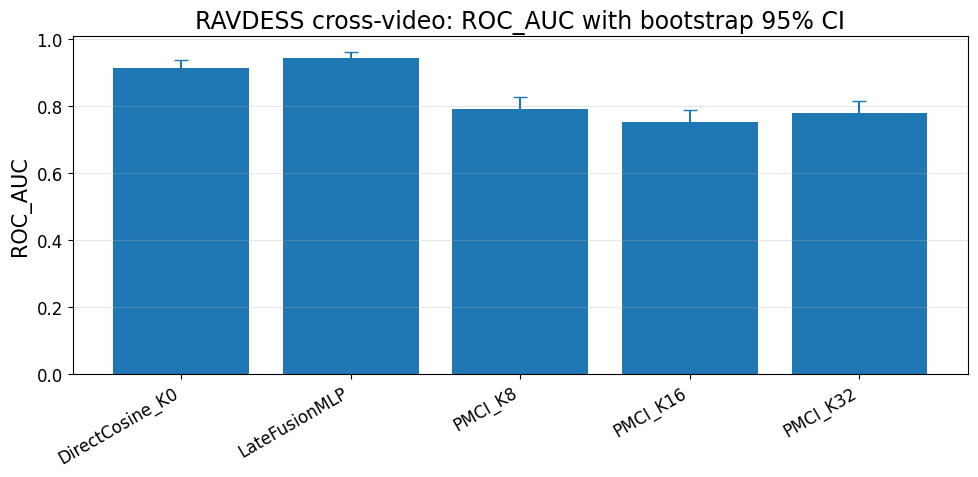

Saved: /content/cias_q1_min/results_q1_final_extra_evidence/figures/extra_ravdess_cross_roc_auc_bootstrap_ci.png
Saved: /content/cias_q1_min/results_q1_final_extra_evidence/figures/extra_ravdess_cross_roc_auc_bootstrap_ci.pdf


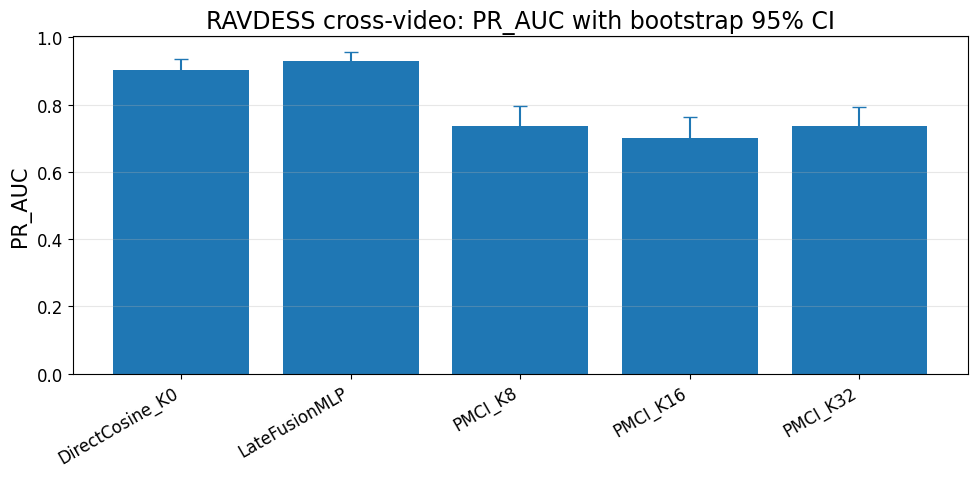

Saved: /content/cias_q1_min/results_q1_final_extra_evidence/figures/extra_ravdess_cross_pr_auc_bootstrap_ci.png
Saved: /content/cias_q1_min/results_q1_final_extra_evidence/figures/extra_ravdess_cross_pr_auc_bootstrap_ci.pdf


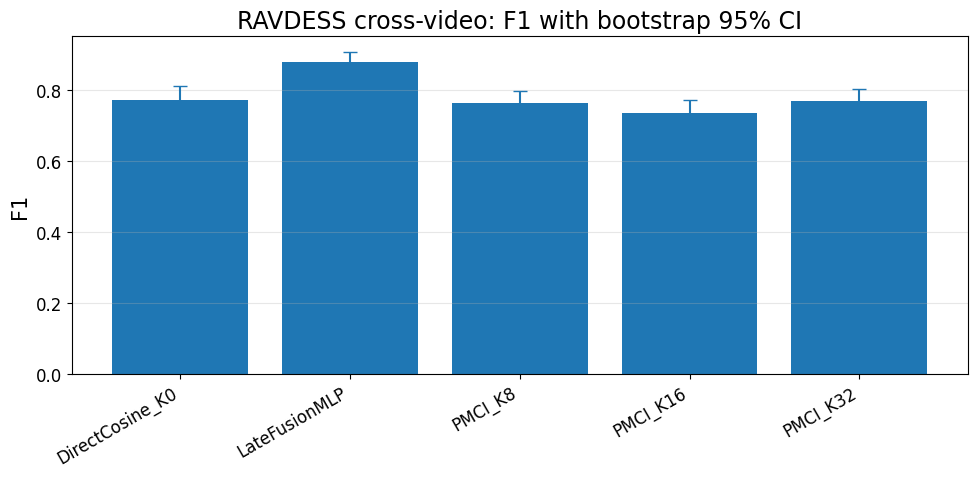

Saved: /content/cias_q1_min/results_q1_final_extra_evidence/figures/extra_ravdess_cross_f1_bootstrap_ci.png
Saved: /content/cias_q1_min/results_q1_final_extra_evidence/figures/extra_ravdess_cross_f1_bootstrap_ci.pdf


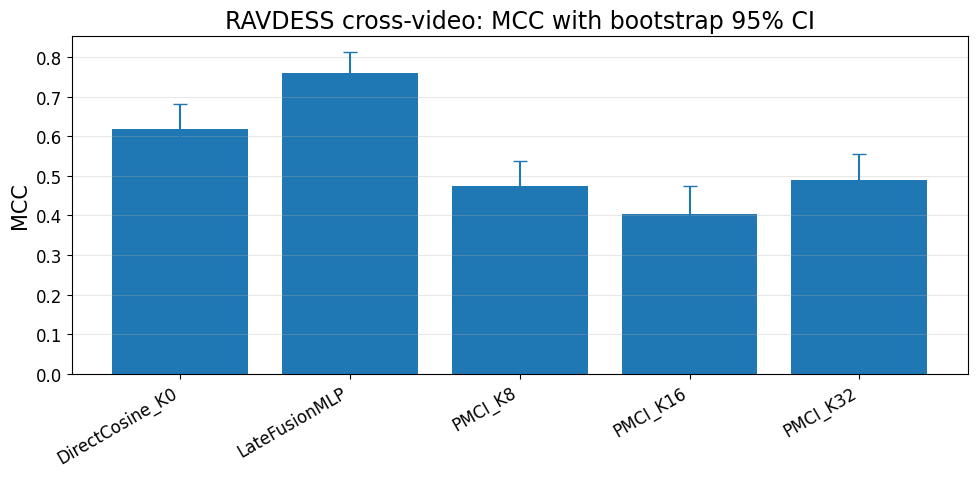

Saved: /content/cias_q1_min/results_q1_final_extra_evidence/figures/extra_ravdess_cross_mcc_bootstrap_ci.png
Saved: /content/cias_q1_min/results_q1_final_extra_evidence/figures/extra_ravdess_cross_mcc_bootstrap_ci.pdf


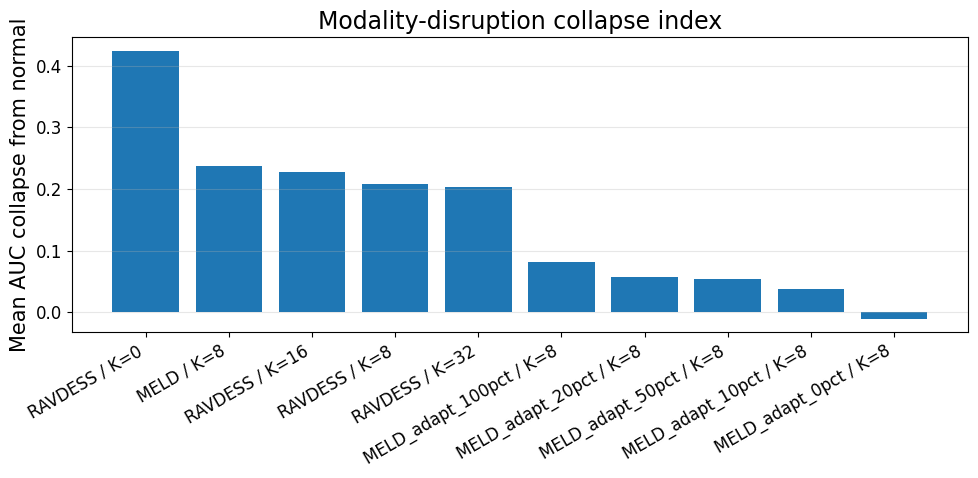

Saved: /content/cias_q1_min/results_q1_final_extra_evidence/figures/extra_modality_collapse_index.png
Saved: /content/cias_q1_min/results_q1_final_extra_evidence/figures/extra_modality_collapse_index.pdf


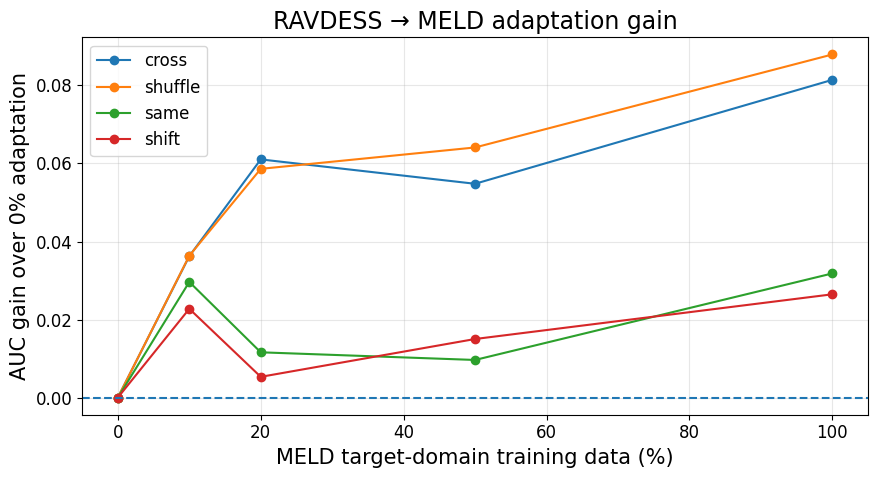

Saved: /content/cias_q1_min/results_q1_final_extra_evidence/figures/extra_adaptation_gain.png
Saved: /content/cias_q1_min/results_q1_final_extra_evidence/figures/extra_adaptation_gain.pdf


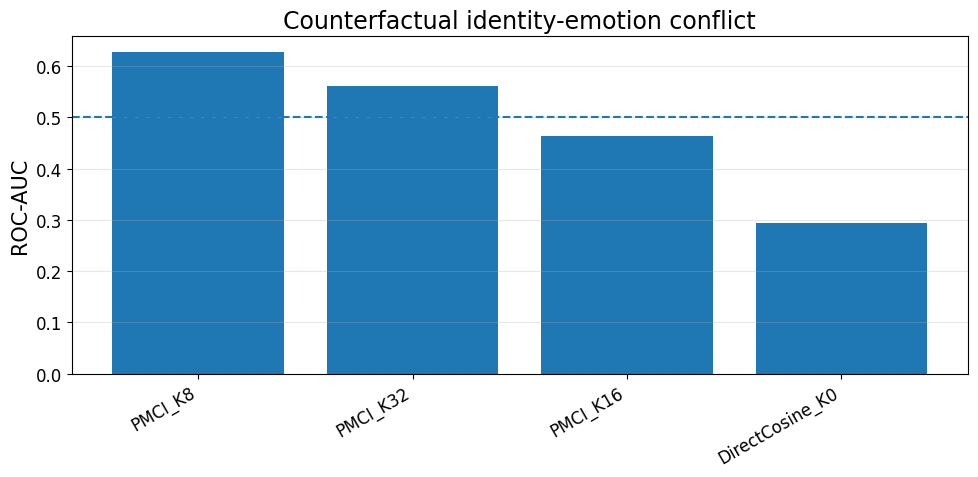

Saved: /content/cias_q1_min/results_q1_final_extra_evidence/figures/extra_counterfactual_identity_emotion_conflict_mainrun.png
Saved: /content/cias_q1_min/results_q1_final_extra_evidence/figures/extra_counterfactual_identity_emotion_conflict_mainrun.pdf


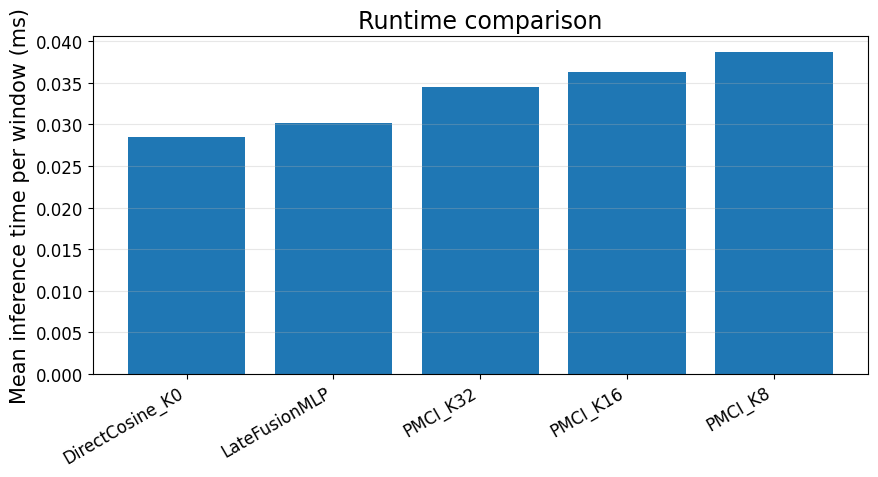

Saved: /content/cias_q1_min/results_q1_final_extra_evidence/figures/extra_runtime_comparison.png
Saved: /content/cias_q1_min/results_q1_final_extra_evidence/figures/extra_runtime_comparison.pdf

DONE.
All final extra evidence saved to: /content/cias_q1_min/results_q1_final_extra_evidence
Summary JSON: /content/cias_q1_min/results_q1_final_extra_evidence/README_extra_evidence_summary.json

Key files:
bootstrap_ci -> /content/cias_q1_min/results_q1_final_extra_evidence/extra_bootstrap_ci_metrics.csv
paired_comparisons -> /content/cias_q1_min/results_q1_final_extra_evidence/extra_paired_auc_comparisons_summary.csv
modality_collapse -> /content/cias_q1_min/results_q1_final_extra_evidence/extra_modality_collapse_summary.csv
adaptation_gain -> /content/cias_q1_min/results_q1_final_extra_evidence/extra_adaptation_gain.csv
counterfactual_key -> /content/cias_q1_min/results_q1_final_extra_evidence/extra_counterfactual_key_table.csv
counterfactual_advantage -> /content/cias_q1_min/results_q1_fin

In [ ]:
# ============================================================
# FIXED PART: EXPERIMENT 3 onward
# Use after the previous cell stopped at KeyError: 'auc_mean'
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
import json
import re

# ------------------------------------------------------------
# FIX: create summary versions because original CSVs use "auc"
# ------------------------------------------------------------

drop_summary_src = (
    drop_csv
    .groupby(["dataset", "k_proto", "control"], as_index=False)
    .agg(
        auc_mean=("auc", "mean"),
        auc_std=("auc", "std"),
        pos_mean=("pos_mean", "mean"),
        neg_mean=("neg_mean", "mean"),
    )
)

main_summary_src = (
    main_csv
    .groupby(["experiment", "train", "test", "k_proto", "regime"], as_index=False)
    .agg(
        auc_mean=("auc", "mean"),
        auc_std=("auc", "std"),
        pos_mean=("pos_mean", "mean"),
        neg_mean=("neg_mean", "mean"),
    )
)

cf_summary_src = (
    cf_csv
    .groupby(["k_proto", "comparison"], as_index=False)
    .agg(
        auc_mean=("auc", "mean"),
        auc_std=("auc", "std"),
        p_perm_mean=("p_perm", "mean"),
        cohen_d_mean=("cohen_d", "mean"),
        pos_mean=("pos_mean", "mean"),
        neg_mean=("neg_mean", "mean"),
    )
)

print("drop_summary_src:")
display(drop_summary_src.head())

print("main_summary_src:")
display(main_summary_src.head())

print("cf_summary_src:")
display(cf_summary_src.head())


# ============================================================
# EXPERIMENT 3: MODALITY-COLLAPSE INDEX
# ============================================================

collapse_rows = []

for keys, g in drop_summary_src.groupby(["dataset", "k_proto"]):
    dataset, k = keys

    if "normal" not in set(g["control"]):
        continue

    normal_auc = float(g[g["control"] == "normal"]["auc_mean"].iloc[0])

    for control in ["face_zero", "body_zero", "body_batch_shuffle", "body_shuffle"]:
        gg = g[g["control"] == control]
        if len(gg) == 0:
            continue

        control_auc = float(gg["auc_mean"].iloc[0])

        collapse_rows.append({
            "dataset": dataset,
            "k_proto": k,
            "normal_auc": normal_auc,
            "control": control,
            "control_auc": control_auc,
            "collapse_delta": normal_auc - control_auc,
            "abs_distance_to_chance": abs(control_auc - 0.5),
        })

collapse_df = pd.DataFrame(collapse_rows)

collapse_summary = collapse_df.groupby(["dataset", "k_proto"]).agg(
    normal_auc=("normal_auc", "first"),
    mean_collapse_delta=("collapse_delta", "mean"),
    max_abs_distance_to_chance=("abs_distance_to_chance", "max"),
).reset_index()

collapse_path = f"{OUT_DIR}/extra_modality_collapse_index.csv"
collapse_summary_path = f"{OUT_DIR}/extra_modality_collapse_summary.csv"

collapse_df.to_csv(collapse_path, index=False)
collapse_summary.to_csv(collapse_summary_path, index=False)

print("\nSaved modality collapse:")
print(collapse_path)
print(collapse_summary_path)
display(collapse_summary)


# ============================================================
# EXPERIMENT 4: DOMAIN ADAPTATION GAIN
# ============================================================

adapt = main_summary_src[
    main_summary_src["experiment"].astype(str).str.contains("ravdess_to_meld_adapt", na=False)
].copy()

def parse_pct(exp):
    m = re.search(r"adapt_(\d+)pct", str(exp))
    return int(m.group(1)) if m else np.nan

adapt["target_meld_pct"] = adapt["experiment"].apply(parse_pct)

adapt_gain_rows = []

for regime in ["cross", "same", "shift", "shuffle"]:
    g = adapt[adapt["regime"] == regime].copy()
    if len(g) == 0:
        continue

    base = g[g["target_meld_pct"] == 0]
    if len(base) == 0:
        continue

    base_auc = float(base["auc_mean"].iloc[0])

    for _, r in g.iterrows():
        adapt_gain_rows.append({
            "regime": regime,
            "target_meld_pct": r["target_meld_pct"],
            "auc_mean": r["auc_mean"],
            "auc_std": r["auc_std"],
            "gain_vs_0pct": r["auc_mean"] - base_auc,
        })

adapt_gain_df = pd.DataFrame(adapt_gain_rows).sort_values(["regime", "target_meld_pct"])

adapt_gain_path = f"{OUT_DIR}/extra_adaptation_gain.csv"
adapt_gain_df.to_csv(adapt_gain_path, index=False)

print("\nSaved adaptation gain:", adapt_gain_path)
display(adapt_gain_df)


# ============================================================
# EXPERIMENT 5: COUNTERFACTUAL ADVANTAGE FROM ORIGINAL MAIN RUN
# ============================================================

cf_adv = cf_summary_src.copy()

cf_adv["model_label"] = cf_adv["k_proto"].apply(
    lambda k: "DirectCosine_K0" if int(k) == 0 else f"PMCI_K{int(k)}"
)

key_cf = cf_adv[
    cf_adv["comparison"].astype(str).str.contains("same_emotion", case=False, na=False) &
    cf_adv["comparison"].astype(str).str.contains("same_actor", case=False, na=False)
].copy()

if len(key_cf) == 0:
    key_cf = cf_adv.copy()

key_cf = key_cf.sort_values("auc_mean", ascending=False)

direct = key_cf[key_cf["model_label"] == "DirectCosine_K0"]
pmci8 = key_cf[key_cf["model_label"] == "PMCI_K8"]

if len(direct) and len(pmci8):
    direct_auc = float(direct["auc_mean"].iloc[0])
    pmci8_auc = float(pmci8["auc_mean"].iloc[0])
    advantage = pmci8_auc - direct_auc
else:
    direct_auc = np.nan
    pmci8_auc = np.nan
    advantage = np.nan

cf_advantage_summary = pd.DataFrame([{
    "direct_auc": direct_auc,
    "pmci8_auc": pmci8_auc,
    "pmci8_minus_direct": advantage,
    "interpretation": "positive value means PMCI_K8 is better than DirectCosine in the identity-emotion conflict comparison"
}])

cf_adv_path = f"{OUT_DIR}/extra_counterfactual_key_table.csv"
cf_adv_summary_path = f"{OUT_DIR}/extra_counterfactual_advantage_summary.csv"

key_cf.to_csv(cf_adv_path, index=False)
cf_advantage_summary.to_csv(cf_adv_summary_path, index=False)

print("\nSaved counterfactual evidence:")
print(cf_adv_path)
print(cf_adv_summary_path)
display(key_cf)
display(cf_advantage_summary)


# ============================================================
# EXPERIMENT 6: RUNTIME COMPACT TABLE
# ============================================================

runtime_out = runtime_csv.copy()

runtime_out_path = f"{OUT_DIR}/extra_runtime_compact.csv"
runtime_out.to_csv(runtime_out_path, index=False)

print("\nSaved runtime compact:", runtime_out_path)
display(runtime_out)


# ============================================================
# PAPER-READY FIGURES
# ============================================================

plt.rcParams.update({
    "font.size": 14,
    "axes.titlesize": 17,
    "axes.labelsize": 15,
    "legend.fontsize": 12,
    "xtick.labelsize": 12,
    "ytick.labelsize": 12,
})

def save_fig(name):
    path_png = f"{FIG_DIR}/{name}.png"
    path_pdf = f"{FIG_DIR}/{name}.pdf"
    plt.tight_layout()
    plt.savefig(path_png, dpi=300, bbox_inches="tight")
    plt.savefig(path_pdf, bbox_inches="tight")
    plt.show()
    print("Saved:", path_png)
    print("Saved:", path_pdf)


# Figure A: bootstrap metrics for RAVDESS cross
fig_df = bootstrap_df[
    (bootstrap_df["dataset"] == "RAVDESS") &
    (bootstrap_df["regime"] == "cross") &
    (bootstrap_df["score_name"] == "main") &
    (bootstrap_df["model"].isin(["DirectCosine_K0", "LateFusionMLP", "PMCI_K8", "PMCI_K16", "PMCI_K32"]))
].copy()

if len(fig_df):
    order = ["DirectCosine_K0", "LateFusionMLP", "PMCI_K8", "PMCI_K16", "PMCI_K32"]
    fig_df["order"] = fig_df["model"].apply(lambda x: order.index(x) if x in order else 99)
    fig_df = fig_df.sort_values("order")

    for metric in ["roc_auc", "pr_auc", "f1", "mcc"]:
        plt.figure(figsize=(10, 5))
        x = np.arange(len(fig_df))
        y = fig_df[metric].values
        low = fig_df[f"{metric}_ci_low"].values
        high = fig_df[f"{metric}_ci_high"].values
        yerr = np.vstack([y - low, high - y])

        plt.bar(x, y)
        plt.errorbar(x, y, yerr=yerr, fmt="none", capsize=5)
        plt.xticks(x, fig_df["model"].values, rotation=30, ha="right")
        plt.ylabel(metric.upper())
        plt.title(f"RAVDESS cross-video: {metric.upper()} with bootstrap 95% CI")
        plt.grid(axis="y", alpha=0.3)
        save_fig(f"extra_ravdess_cross_{metric}_bootstrap_ci")


# Figure B: modality collapse
if len(collapse_summary):
    tmp = collapse_summary.copy()
    tmp["label"] = tmp["dataset"].astype(str) + " / K=" + tmp["k_proto"].astype(str)
    tmp = tmp.sort_values("mean_collapse_delta", ascending=False)

    plt.figure(figsize=(10, 5))
    x = np.arange(len(tmp))
    plt.bar(x, tmp["mean_collapse_delta"].values)
    plt.xticks(x, tmp["label"].values, rotation=30, ha="right")
    plt.ylabel("Mean AUC collapse from normal")
    plt.title("Modality-disruption collapse index")
    plt.grid(axis="y", alpha=0.3)
    save_fig("extra_modality_collapse_index")


# Figure C: adaptation gain
if len(adapt_gain_df):
    plt.figure(figsize=(9, 5))

    for regime in ["cross", "shuffle", "same", "shift"]:
        g = adapt_gain_df[adapt_gain_df["regime"] == regime].sort_values("target_meld_pct")
        if len(g):
            plt.plot(g["target_meld_pct"], g["gain_vs_0pct"], marker="o", label=regime)

    plt.axhline(0, linestyle="--")
    plt.xlabel("MELD target-domain training data (%)")
    plt.ylabel("AUC gain over 0% adaptation")
    plt.title("RAVDESS → MELD adaptation gain")
    plt.legend()
    plt.grid(alpha=0.3)
    save_fig("extra_adaptation_gain")


# Figure D: counterfactual key comparison
if len(key_cf):
    tmp = key_cf.copy()
    tmp = tmp.drop_duplicates(subset=["model_label"])
    tmp = tmp.sort_values("auc_mean", ascending=False)

    plt.figure(figsize=(10, 5))
    x = np.arange(len(tmp))
    plt.bar(x, tmp["auc_mean"].values)
    plt.axhline(0.5, linestyle="--")
    plt.xticks(x, tmp["model_label"].astype(str).values, rotation=30, ha="right")
    plt.ylabel("ROC-AUC")
    plt.title("Counterfactual identity-emotion conflict")
    plt.grid(axis="y", alpha=0.3)
    save_fig("extra_counterfactual_identity_emotion_conflict_mainrun")


# Figure E: runtime
if len(runtime_out):
    metric_col = None
    for c in runtime_out.columns:
        if "mean_window_time_ms_mean" in c:
            metric_col = c
            break
    if metric_col is None:
        for c in runtime_out.columns:
            if "window" in c.lower() and "ms" in c.lower():
                metric_col = c
                break

    if metric_col is not None:
        tmp = runtime_out.sort_values(metric_col)

        plt.figure(figsize=(9, 5))
        x = np.arange(len(tmp))
        plt.bar(x, tmp[metric_col].values)
        plt.xticks(x, tmp["model"].astype(str).values, rotation=30, ha="right")
        plt.ylabel("Mean inference time per window (ms)")
        plt.title("Runtime comparison")
        plt.grid(axis="y", alpha=0.3)
        save_fig("extra_runtime_comparison")


# ============================================================
# FINAL SUMMARY
# ============================================================

summary = {
    "created_files": {
        "bootstrap_ci": bootstrap_path,
        "paired_comparisons": paired_summary_path,
        "modality_collapse": collapse_summary_path,
        "adaptation_gain": adapt_gain_path,
        "counterfactual_key": cf_adv_path,
        "counterfactual_advantage": cf_adv_summary_path,
        "runtime": runtime_out_path,
        "figures": FIG_DIR,
    },
    "recommended_use": {
        "use_in_main_text": [
            "extended metrics table",
            "LateFusionMLP baseline table",
            "modality-collapse index",
            "adaptation gain",
            "runtime compact table"
        ],
        "use_old_main_run_for": [
            "identity leakage",
            "balanced counterfactual PMCI vs DirectCosine"
        ],
        "avoid": [
            "new retrained identity-leakage extended graph",
            "new retrained counterfactual extended graph if it contradicts the main run"
        ]
    }
}

summary_path = f"{OUT_DIR}/README_extra_evidence_summary.json"
Path(summary_path).write_text(json.dumps(summary, indent=2))

print("\nDONE.")
print("All final extra evidence saved to:", OUT_DIR)
print("Summary JSON:", summary_path)

print("\nKey files:")
for k, v in summary["created_files"].items():
    print(k, "->", v)